# 2.1. GIẢI THUẬT 1: CÂY QUYẾT ĐỊNH VÀ RỪNG CÂY

## 2.1.1. Ôn tập lý thuyết

### Quy trình khai phá dữ liệu

1. **CRISP-DM (Cross Industry Standard Process for Data Mining)**:
   - Là một quy trình chuẩn cho khai phá dữ liệu được sử dụng rộng rãi trong ngành
   - Gồm 6 giai đoạn:
     1. Business Understanding (Hiểu biết nghiệp vụ)
     2. Data Understanding (Hiểu biết dữ liệu)  
     3. Data Preparation (Chuẩn bị dữ liệu)
     4. Modeling (Xây dựng mô hình)
     5. Evaluation (Đánh giá)
     6. Deployment (Triển khai)

2. **SEMMA (Sample, Explore, Modify, Model, Access)**:
   - Là quy trình khai phá dữ liệu do SAS Institute phát triển
   - Gồm 5 giai đoạn:
     1. Sample: Lấy mẫu dữ liệu
     2. Explore: Khám phá và phân tích dữ liệu
     3. Modify: Điều chỉnh và chuẩn bị dữ liệu
     4. Model: Xây dựng mô hình
     5. Access: Đánh giá kết quả

### Cây quyết định

1. **Cách hoạt động và thành phần chính**:
   - **Nút gốc (Root node)**: Điểm bắt đầu của cây, chứa toàn bộ dữ liệu
   - **Nút nhánh (Branch/Internal node)**: Các nút trung gian thể hiện điều kiện phân chia
   - **Nút lá (Leaf node)**: Nút cuối cùng chứa kết quả dự đoán
   - **Cách đưa ra dự đoán**: Dữ liệu đi từ nút gốc, qua các nút nhánh theo các điều kiện phân chia, đến nút lá để nhận kết quả

2. **Tiêu chí phân tách (Splitting Criteria)**:
   - **Gini Index**: 
     - Đo lường mức độ không đồng nhất
     - Công thức: Gini = 1 - Σ(pi²) với pi là xác suất của class i
     - Giá trị từ 0 (hoàn toàn đồng nhất) đến 0.5 (hoàn toàn không đồng nhất)
   
   - **Entropy**:
     - Đo lường mức độ hỗn loạn của dữ liệu
     - Công thức: Entropy = -Σ(pi * log₂(pi))
     - Giá trị từ 0 (hoàn toàn đồng nhất) đến 1 (hoàn toàn hỗn loạn)
   
   - **Information Gain**:
     - Mức độ giảm entropy sau khi phân chia
     - Công thức: IG = Entropy(parent) - Weighted_Average(Entropy(children))
     - Chọn thuộc tính có Information Gain cao nhất để phân chia

### Random Forest

1. **Khái niệm và đặc điểm**:
   - Là tập hợp nhiều cây quyết định độc lập
   - Mỗi cây được xây dựng từ một tập mẫu bootstrap của dữ liệu
   - Kết quả cuối cùng là kết hợp dự đoán của tất cả các cây (voting/averaging)

2. **So sánh với cây quyết định đơn lẻ**:
   - Hiệu suất tốt hơn nhờ:
     - Giảm overfitting thông qua việc kết hợp nhiều mô hình
     - Random feature selection giúp tăng tính đa dạng
     - Bootstrap sampling tạo ra dữ liệu huấn luyện khác nhau cho mỗi cây

### Ưu điểm và hạn chế

1. **Cây quyết định**:
   - Ưu điểm:
     - Dễ hiểu và giải thích
     - Có thể xử lý cả dữ liệu số và phân loại
     - Ít yêu cầu tiền xử lý dữ liệu
   - Hạn chế:
     - Dễ bị overfitting
     - Không ổn định (nhạy cảm với nhiễu)
     - Hiệu suất có thể thấp hơn các mô hình phức tạp

2. **Random Forest**:
   - Ưu điểm:
     - Hiệu suất cao hơn cây đơn lẻ
     - Ít bị overfitting hơn
     - Xử lý tốt dữ liệu nhiều chiều
   - Hạn chế:
     - Khó giải thích hơn cây đơn lẻ
     - Tốn nhiều tài nguyên tính toán hơn
     - Cần nhiều dữ liệu huấn luyện hơn

### Code Example: Decision Tree và Random Forest

1. **Xây dựng Decision Tree với scikit-learn**:
   - Import thư viện
   - Chuẩn bị dữ liệu
   - Xây dựng và huấn luyện mô hình
   - Đánh giá kết quả

2. **Triển khai Random Forest**:
   - Các tham số quan trọng:
     - n_estimators: Số lượng cây trong rừng
     - max_depth: Độ sâu tối đa của mỗi cây
     - min_samples_split: Số mẫu tối thiểu để phân tách nút
     - min_samples_leaf: Số mẫu tối thiểu tại nút lá

3. **Feature Importance trong Random Forest**:
   - Sử dụng feature_importances_ attribute
   - Visualization với matplotlib hoặc seaborn

## 2.1.2. Bài làm mẫu

### Bài toán 1: Xây dựng cây quyết định và rừng cây với dữ liệu thẻ tín dụng

**Nguồn dữ liệu**: [Default of Credit Card Clients Dataset](https://www.kaggle.com/datasets/deceneu/default-of-credit-card-clients)

#### Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn

In [34]:
# Import các thư viện cần thiết
import numpy as np  # numerical computation
import pandas as pd  # data wrangling
import matplotlib.pyplot as plt  # plotting package
%matplotlib inline
import matplotlib as mpl  # add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400  # high res figures
import graphviz  # to visualize decision trees

#### 2. Nạp dữ liệu và chuẩn bị features

In [35]:
# Nạp dữ liệu
df = pd.read_csv('data.csv')  # Load the cleaned data
features_response = df.columns.tolist()  # Get a list of column names

# Loại bỏ các cột không cần thiết
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3',
                  'PAY_4', 'PAY_5', 'PAY_6',
                  'EDUCATION_CAT', 'graduate school',
                  'high school', 'none',
                  'others', 'university']
features_response = [item for item in features_response if item not in items_to_remove]
features_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

#### 3. Chuẩn bị dữ liệu cho tập train và tập test

In [36]:
from sklearn.model_selection import train_test_split
from sklearn import tree

# Split the data into training and testing sets using the same random seed
X_train, X_test, y_train, y_test = \
train_test_split(df[features_response[:-1]].values,
                df['default payment next month'].values,
                test_size=0.2, random_state=24)

#### 4. Xây dựng cây quyết định

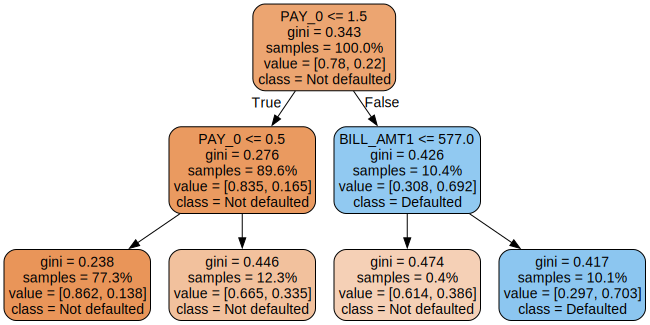

In [37]:
# Xây dựng cây quyết định với độ sâu tối đa là 2
dt = tree.DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

# Hiển thị cây quyết định với package graphviz
dot_data = tree.export_graphviz(dt,
                              out_file=None,
                              filled=True,
                              rounded=True,
                              feature_names=features_response[:-1],
                              proportion=True,
                              class_names=['Not defaulted', 'Defaulted'])
graph = graphviz.Source(dot_data)
graph

### Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định

#### 1. Xác định các tham số cần tối ưu

In [38]:
# Tạo lưới các tham số để tìm kiếm
params = {'max_depth': [1, 2, 4, 6, 8, 10, 12]}  # Các độ sâu khác nhau của cây
dt = tree.DecisionTreeClassifier()  # Khởi tạo mô hình

# Thực hiện GridSearchCV
cv = GridSearchCV(dt, param_grid=params, scoring='roc_auc',
                n_jobs=None, refit=True, cv=4, verbose=1,
                error_score=np.nan,
                return_train_score=True)  # cv là mô hình tốt nhất
cv.fit(X_train, y_train)

print("Tham số tốt nhất:", cv.best_params_)
print("Điểm ROC AUC tốt nhất:", cv.best_score_)

Fitting 4 folds for each of 7 candidates, totalling 28 fits
Tham số tốt nhất: {'max_depth': 6}
Điểm ROC AUC tốt nhất: 0.7438312796811974
Tham số tốt nhất: {'max_depth': 6}
Điểm ROC AUC tốt nhất: 0.7438312796811974


#### 2. Vẽ biểu đồ đánh giá mô hình với các tham số khác nhau

**Giải thích các tham số:**
- scoring = 'roc_auc': Đánh giá mô hình bằng độ đo ROC AUC
- cv = 4: Sử dụng 4-fold cross-validation
- return_train_score = True: Lưu điểm train để đánh giá bias và variance

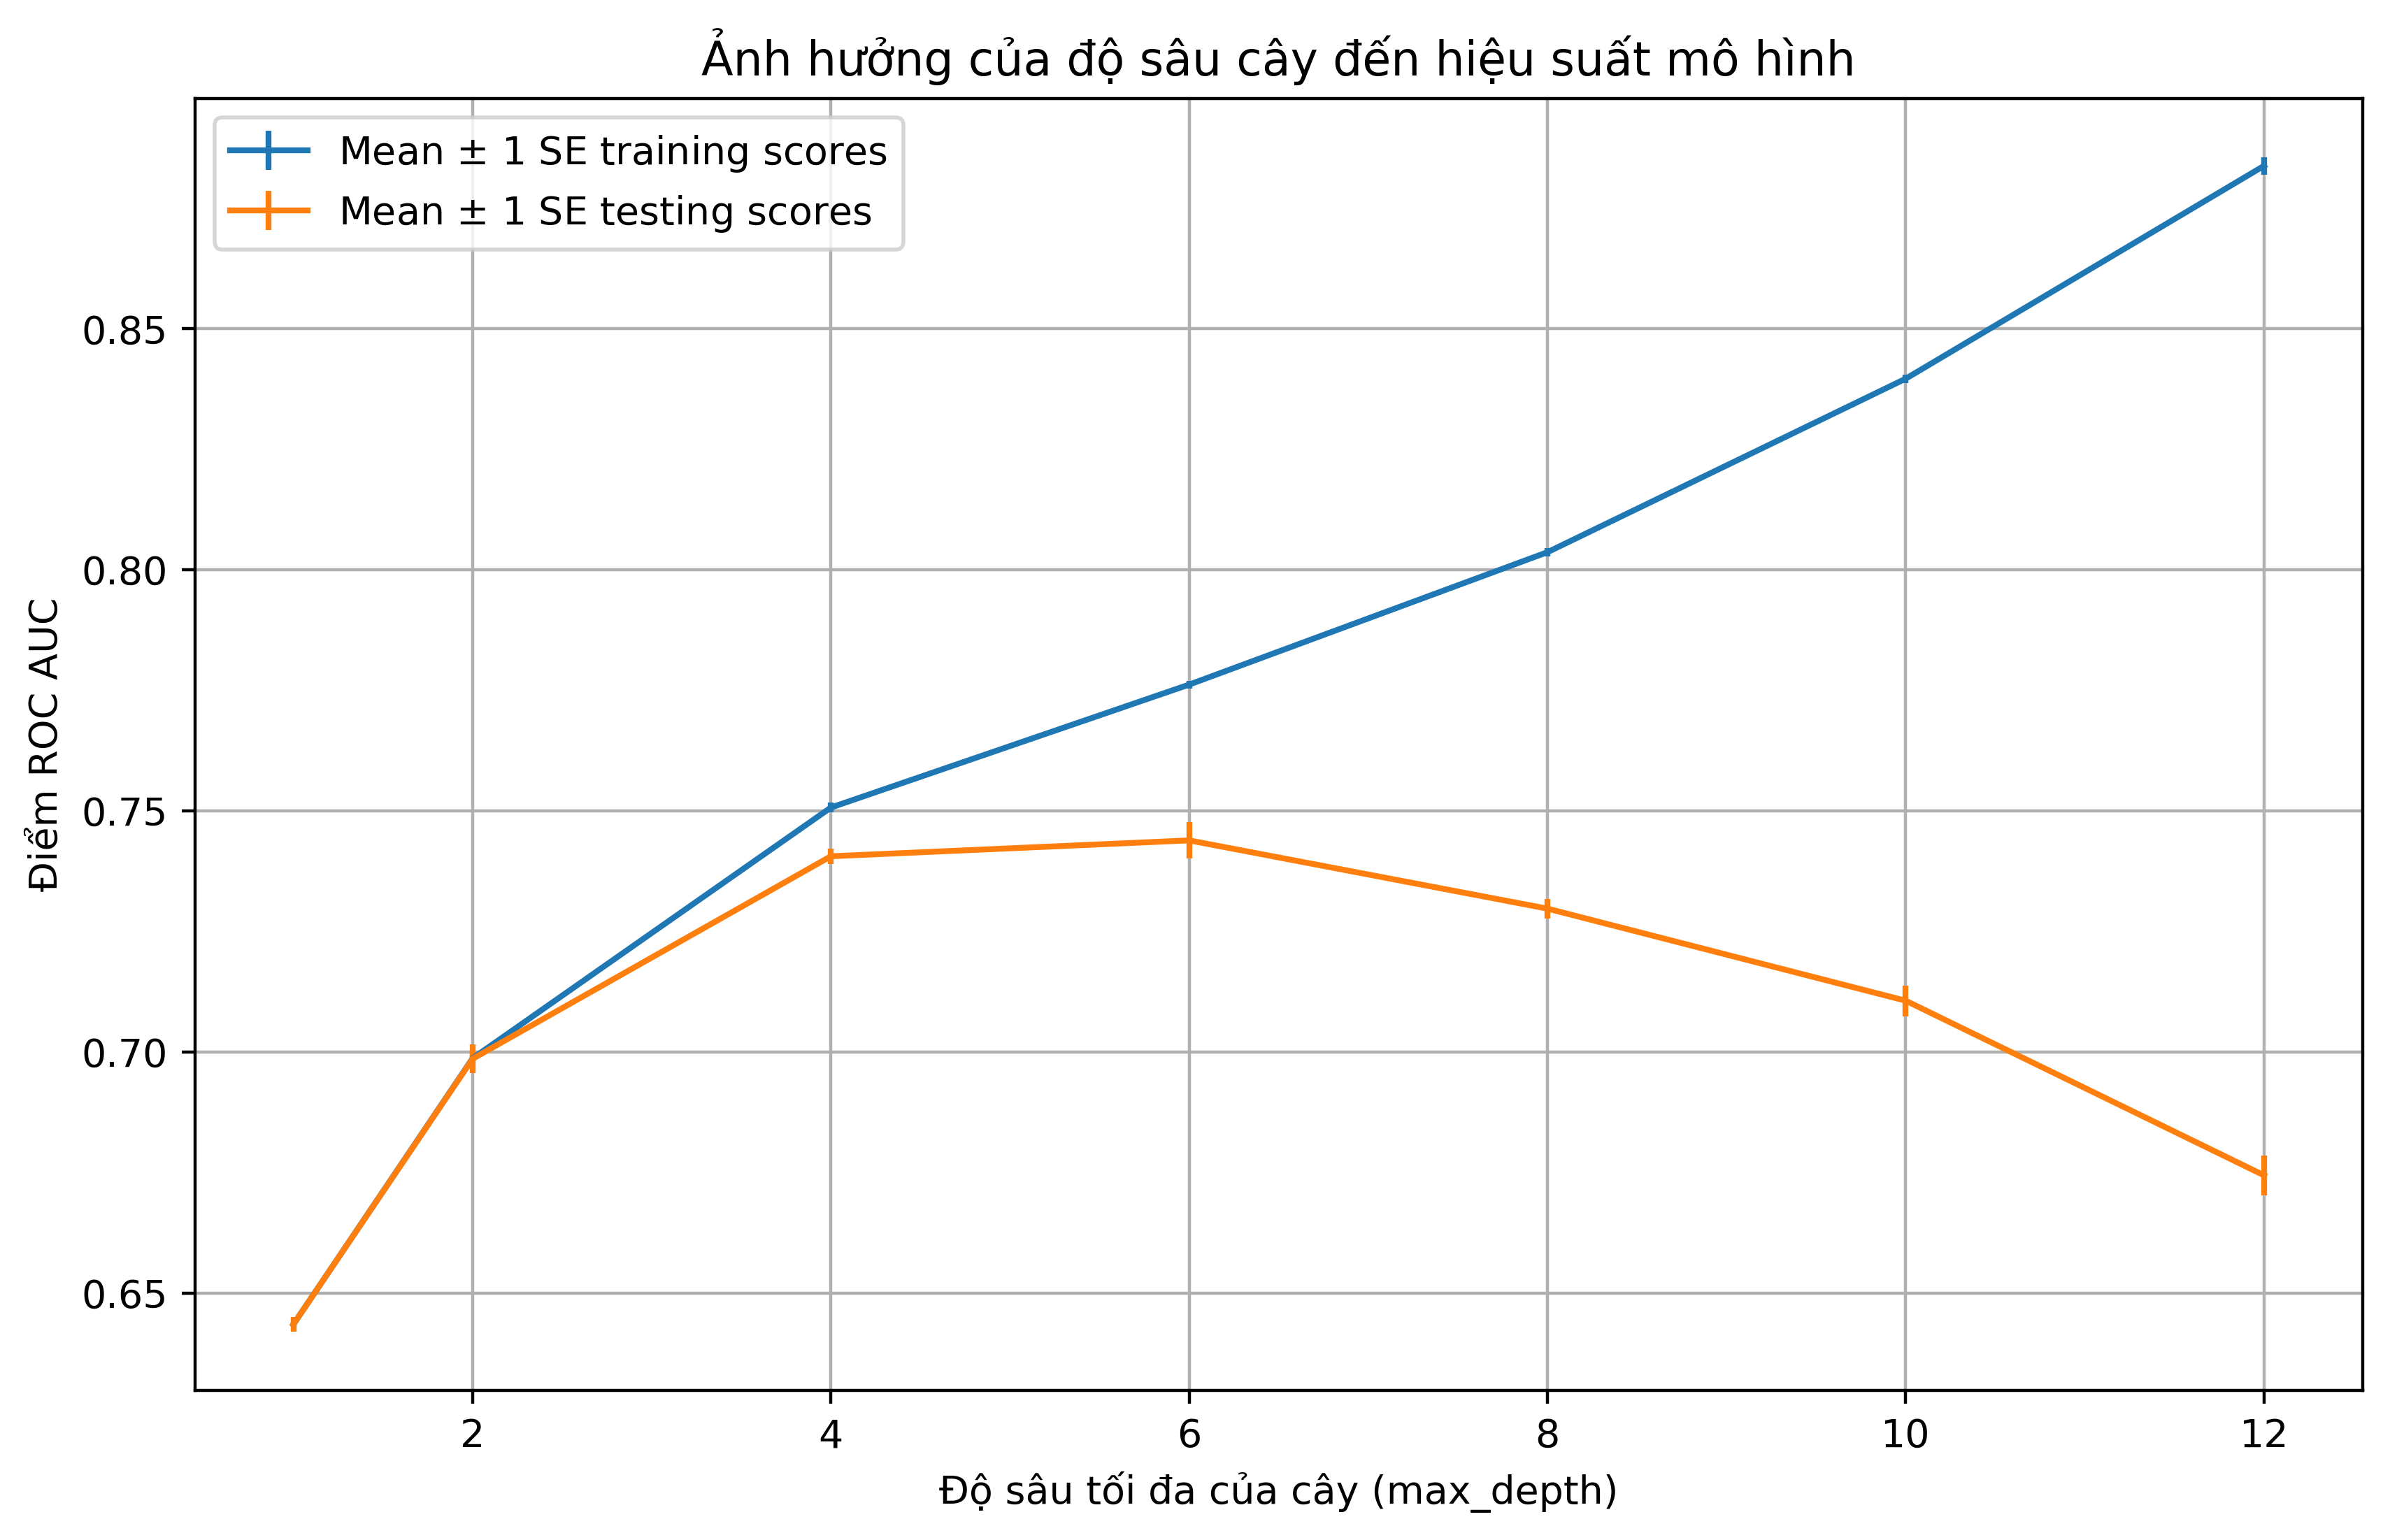

In [39]:
# Tạo DataFrame từ kết quả GridSearchCV
cv_results_df = pd.DataFrame(cv.cv_results_)

# Vẽ biểu đồ so sánh điểm train và test
plt.figure(figsize=(10, 6))
ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
           cv_results_df['mean_train_score'],
           yerr=cv_results_df['std_train_score']/np.sqrt(4),
           label='Mean $\pm$ 1 SE training scores')
ax.errorbar(cv_results_df['param_max_depth'],
           cv_results_df['mean_test_score'],
           yerr=cv_results_df['std_test_score']/np.sqrt(4),
           label='Mean $\pm$ 1 SE testing scores')
ax.legend()
plt.xlabel('Độ sâu tối đa của cây (max_depth)')
plt.ylabel('Điểm ROC AUC')
plt.title('Ảnh hưởng của độ sâu cây đến hiệu suất mô hình')
plt.grid(True)
plt.show()

### Nhiệm vụ 3: Xây dựng rừng cây (Random Forest)

#### 1. Khởi tạo mô hình Random Forest

In [40]:
# Import thư viện cần thiết
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo mô hình Random Forest với các tham số ban đầu
rf = RandomForestClassifier(
    n_estimators=10,           # số lượng cây
    criterion='gini',          # tiêu chí phân tách
    max_depth=3,              # độ sâu tối đa của cây
    min_samples_split=2,      # số mẫu tối thiểu để phân tách
    min_samples_leaf=1,       # số mẫu tối thiểu tại nút lá
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',      # số lượng features được chọn ngẫu nhiên
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,           # sử dụng bootstrap sampling
    oob_score=False,
    n_jobs=None,
    random_state=4,
    verbose=0,
    warm_start=False,
    class_weight=None
)

#### 2. Tìm tham số tối ưu cho mô hình và huấn luyện

In [41]:
# Tạo lưới tham số để tìm số lượng cây tối ưu
rf_params_ex = {'n_estimators': list(range(10, 110, 10))}  # từ 10 đến 100 cây, bước 10

# Thực hiện GridSearchCV
cv_rf_ex = GridSearchCV(
    rf,
    param_grid=rf_params_ex,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)

# Huấn luyện mô hình
cv_rf_ex.fit(X_train, y_train)

print("Tham số tốt nhất:", cv_rf_ex.best_params_)
print("Điểm ROC AUC tốt nhất:", cv_rf_ex.best_score_)

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Tham số tốt nhất: {'n_estimators': 60}
Điểm ROC AUC tốt nhất: 0.7616146663869523
Tham số tốt nhất: {'n_estimators': 60}
Điểm ROC AUC tốt nhất: 0.7616146663869523


#### 3. Vẽ biểu đồ đánh giá mô hình với các tham số khác nhau

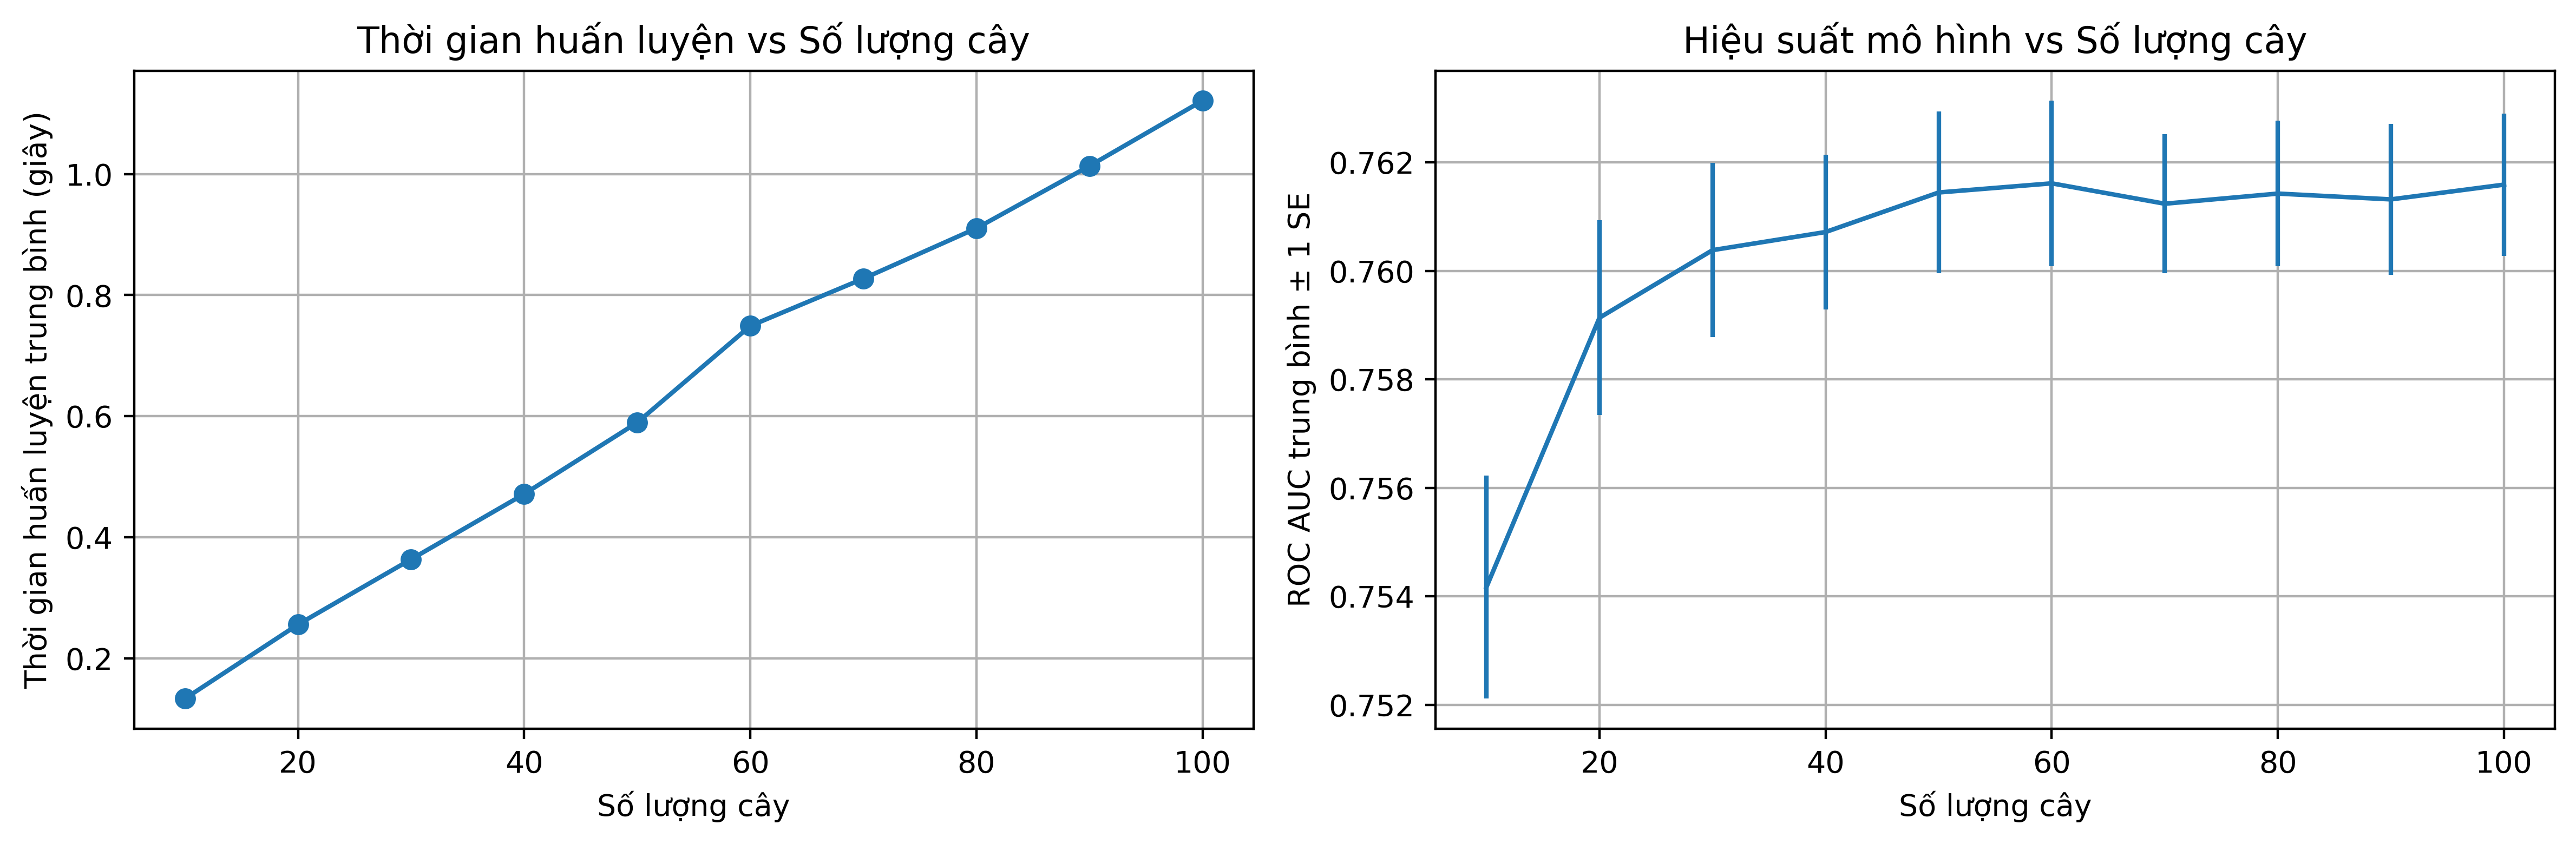

In [42]:
# Tạo DataFrame từ kết quả
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)

# Tạo subplot với 2 biểu đồ
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Biểu đồ 1: Thời gian huấn luyện
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
            cv_rf_ex_results_df['mean_fit_time'],
            '-o')
axs[0].set_xlabel('Số lượng cây')
axs[0].set_ylabel('Thời gian huấn luyện trung bình (giây)')
axs[0].set_title('Thời gian huấn luyện vs Số lượng cây')
axs[0].grid(True)

# Biểu đồ 2: Điểm ROC AUC
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
                cv_rf_ex_results_df['mean_test_score'],
                yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Số lượng cây')
axs[1].set_ylabel('ROC AUC trung bình ± 1 SE')
axs[1].set_title('Hiệu suất mô hình vs Số lượng cây')
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 4. Phân tích mức độ quan trọng của các features

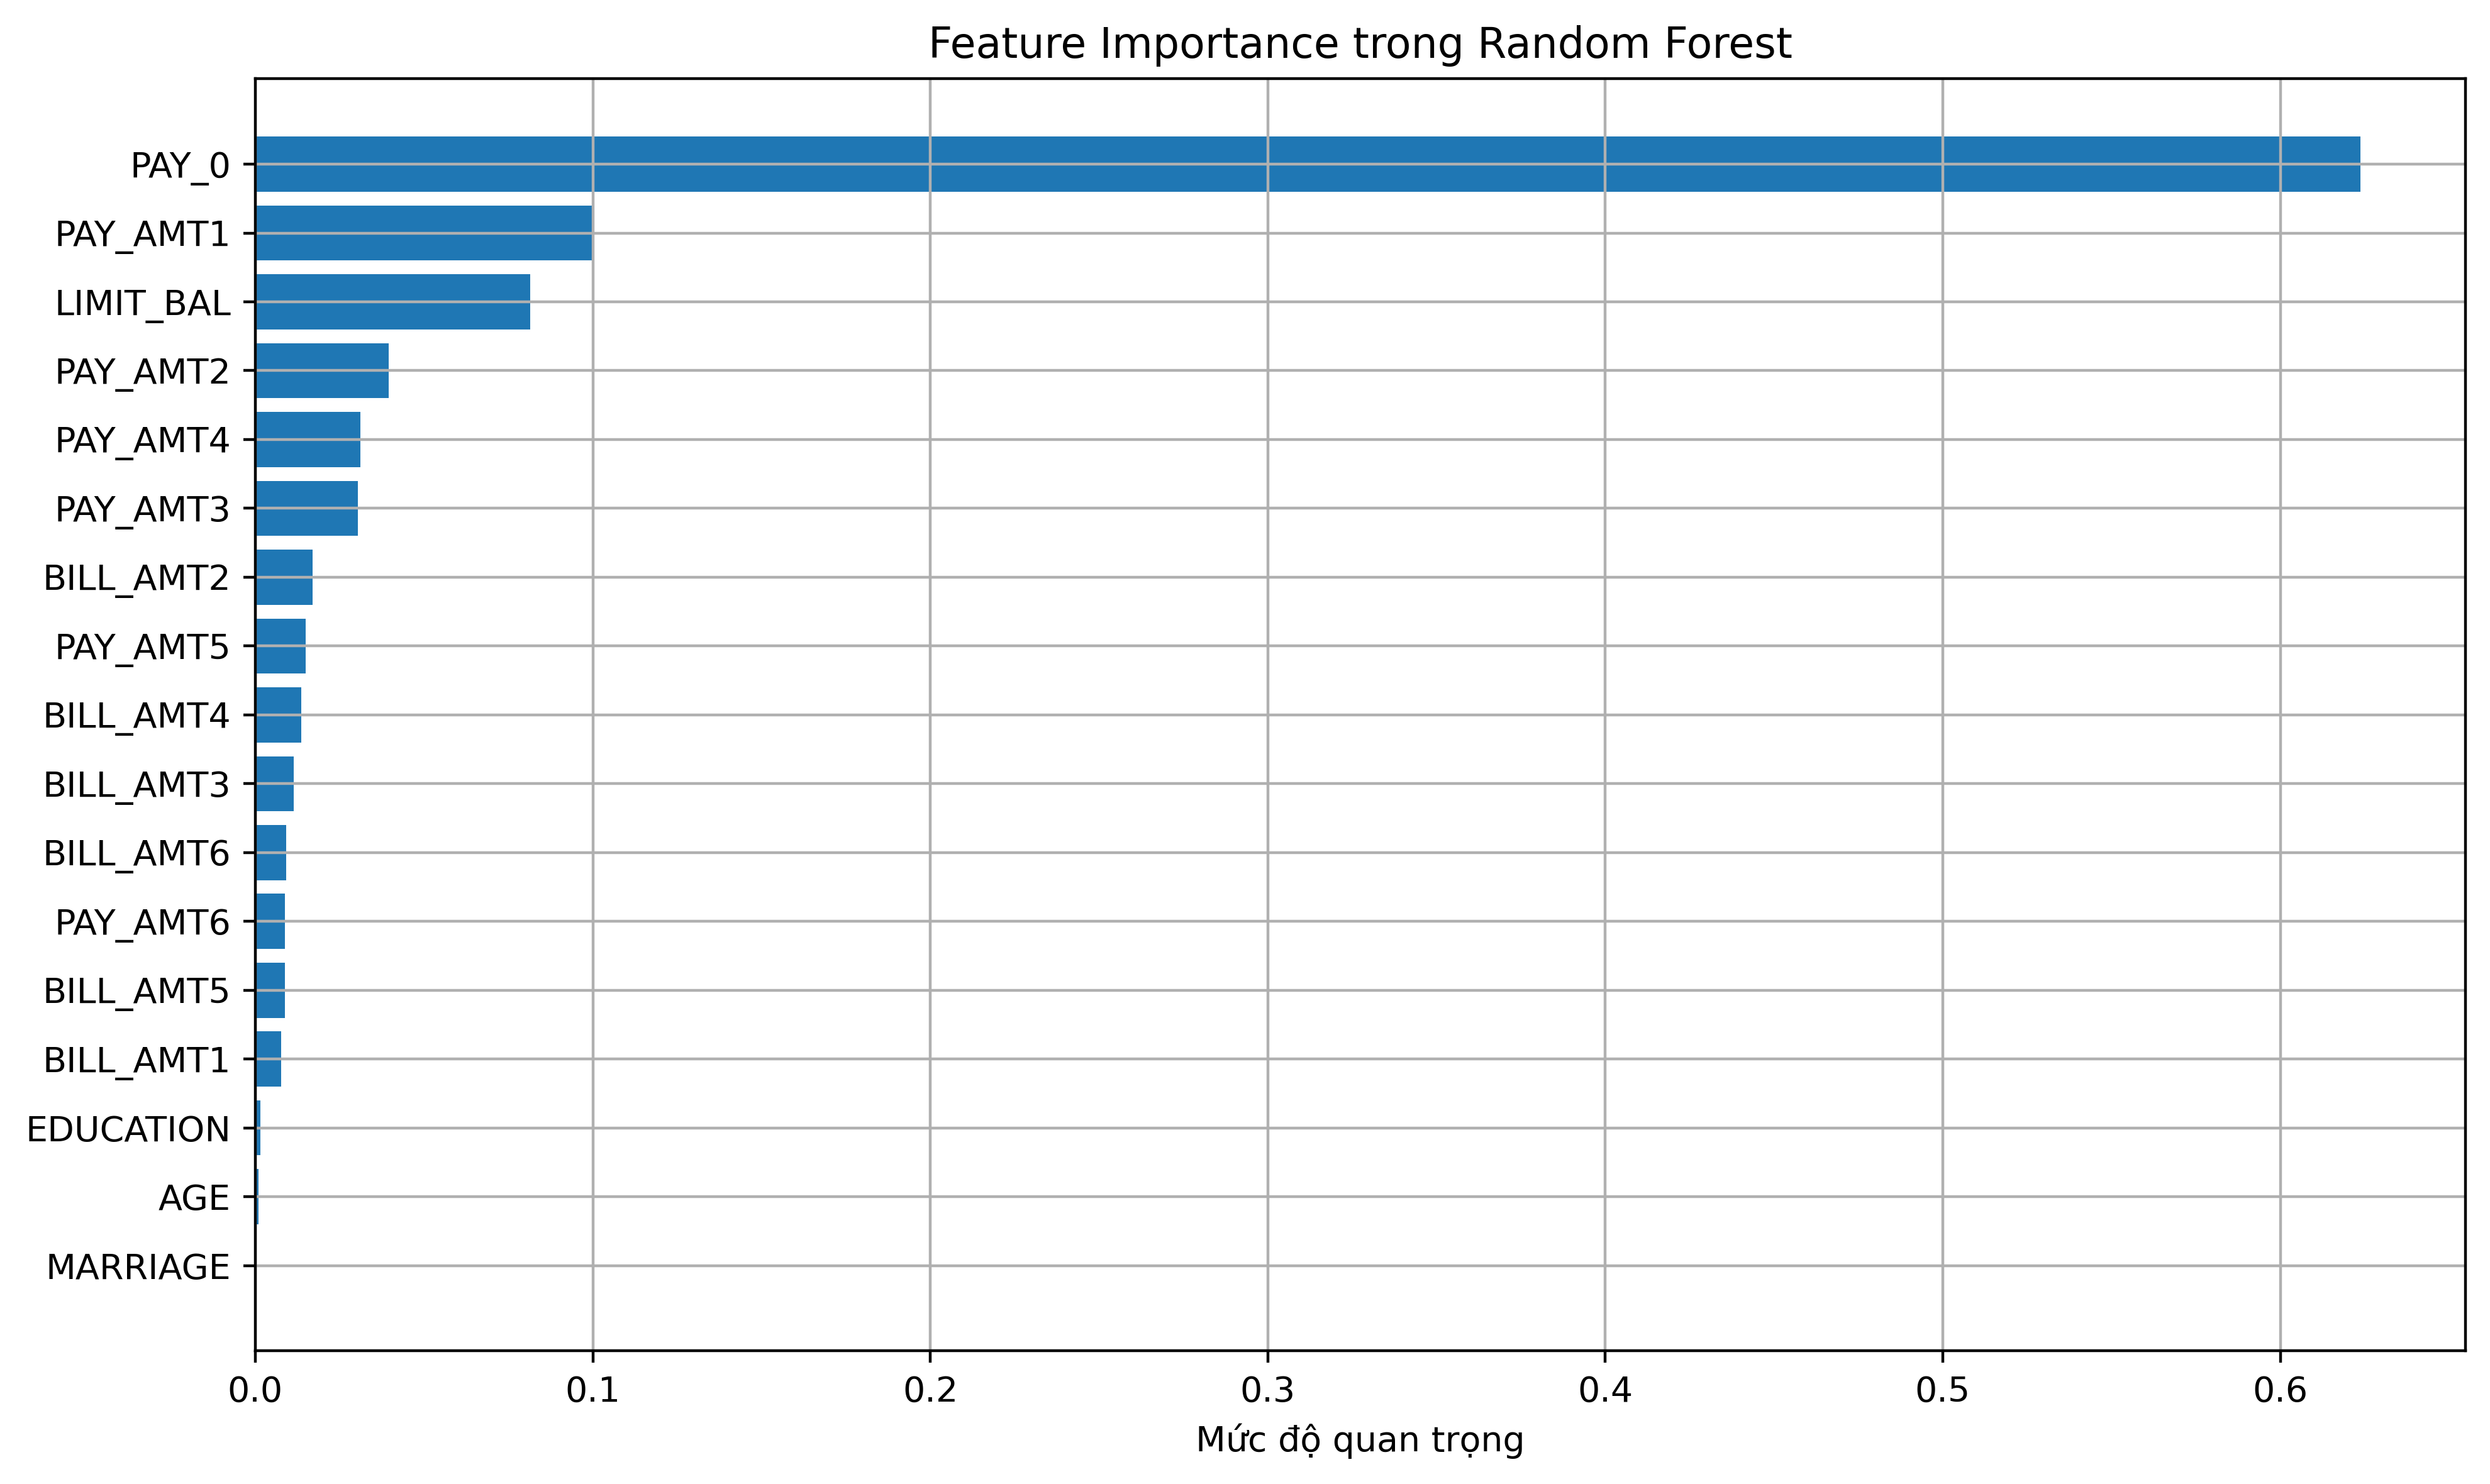

In [43]:
# Tạo DataFrame cho feature importance
feat_imp_df = pd.DataFrame({
    'Feature': features_response[:-1],
    'Importance': cv_rf_ex.best_estimator_.feature_importances_
})

# Sắp xếp theo mức độ quan trọng
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

# Vẽ biểu đồ feature importance
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.xlabel('Mức độ quan trọng')
plt.title('Feature Importance trong Random Forest')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 5. Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV

Fitting 4 folds for each of 7 candidates, totalling 28 fits


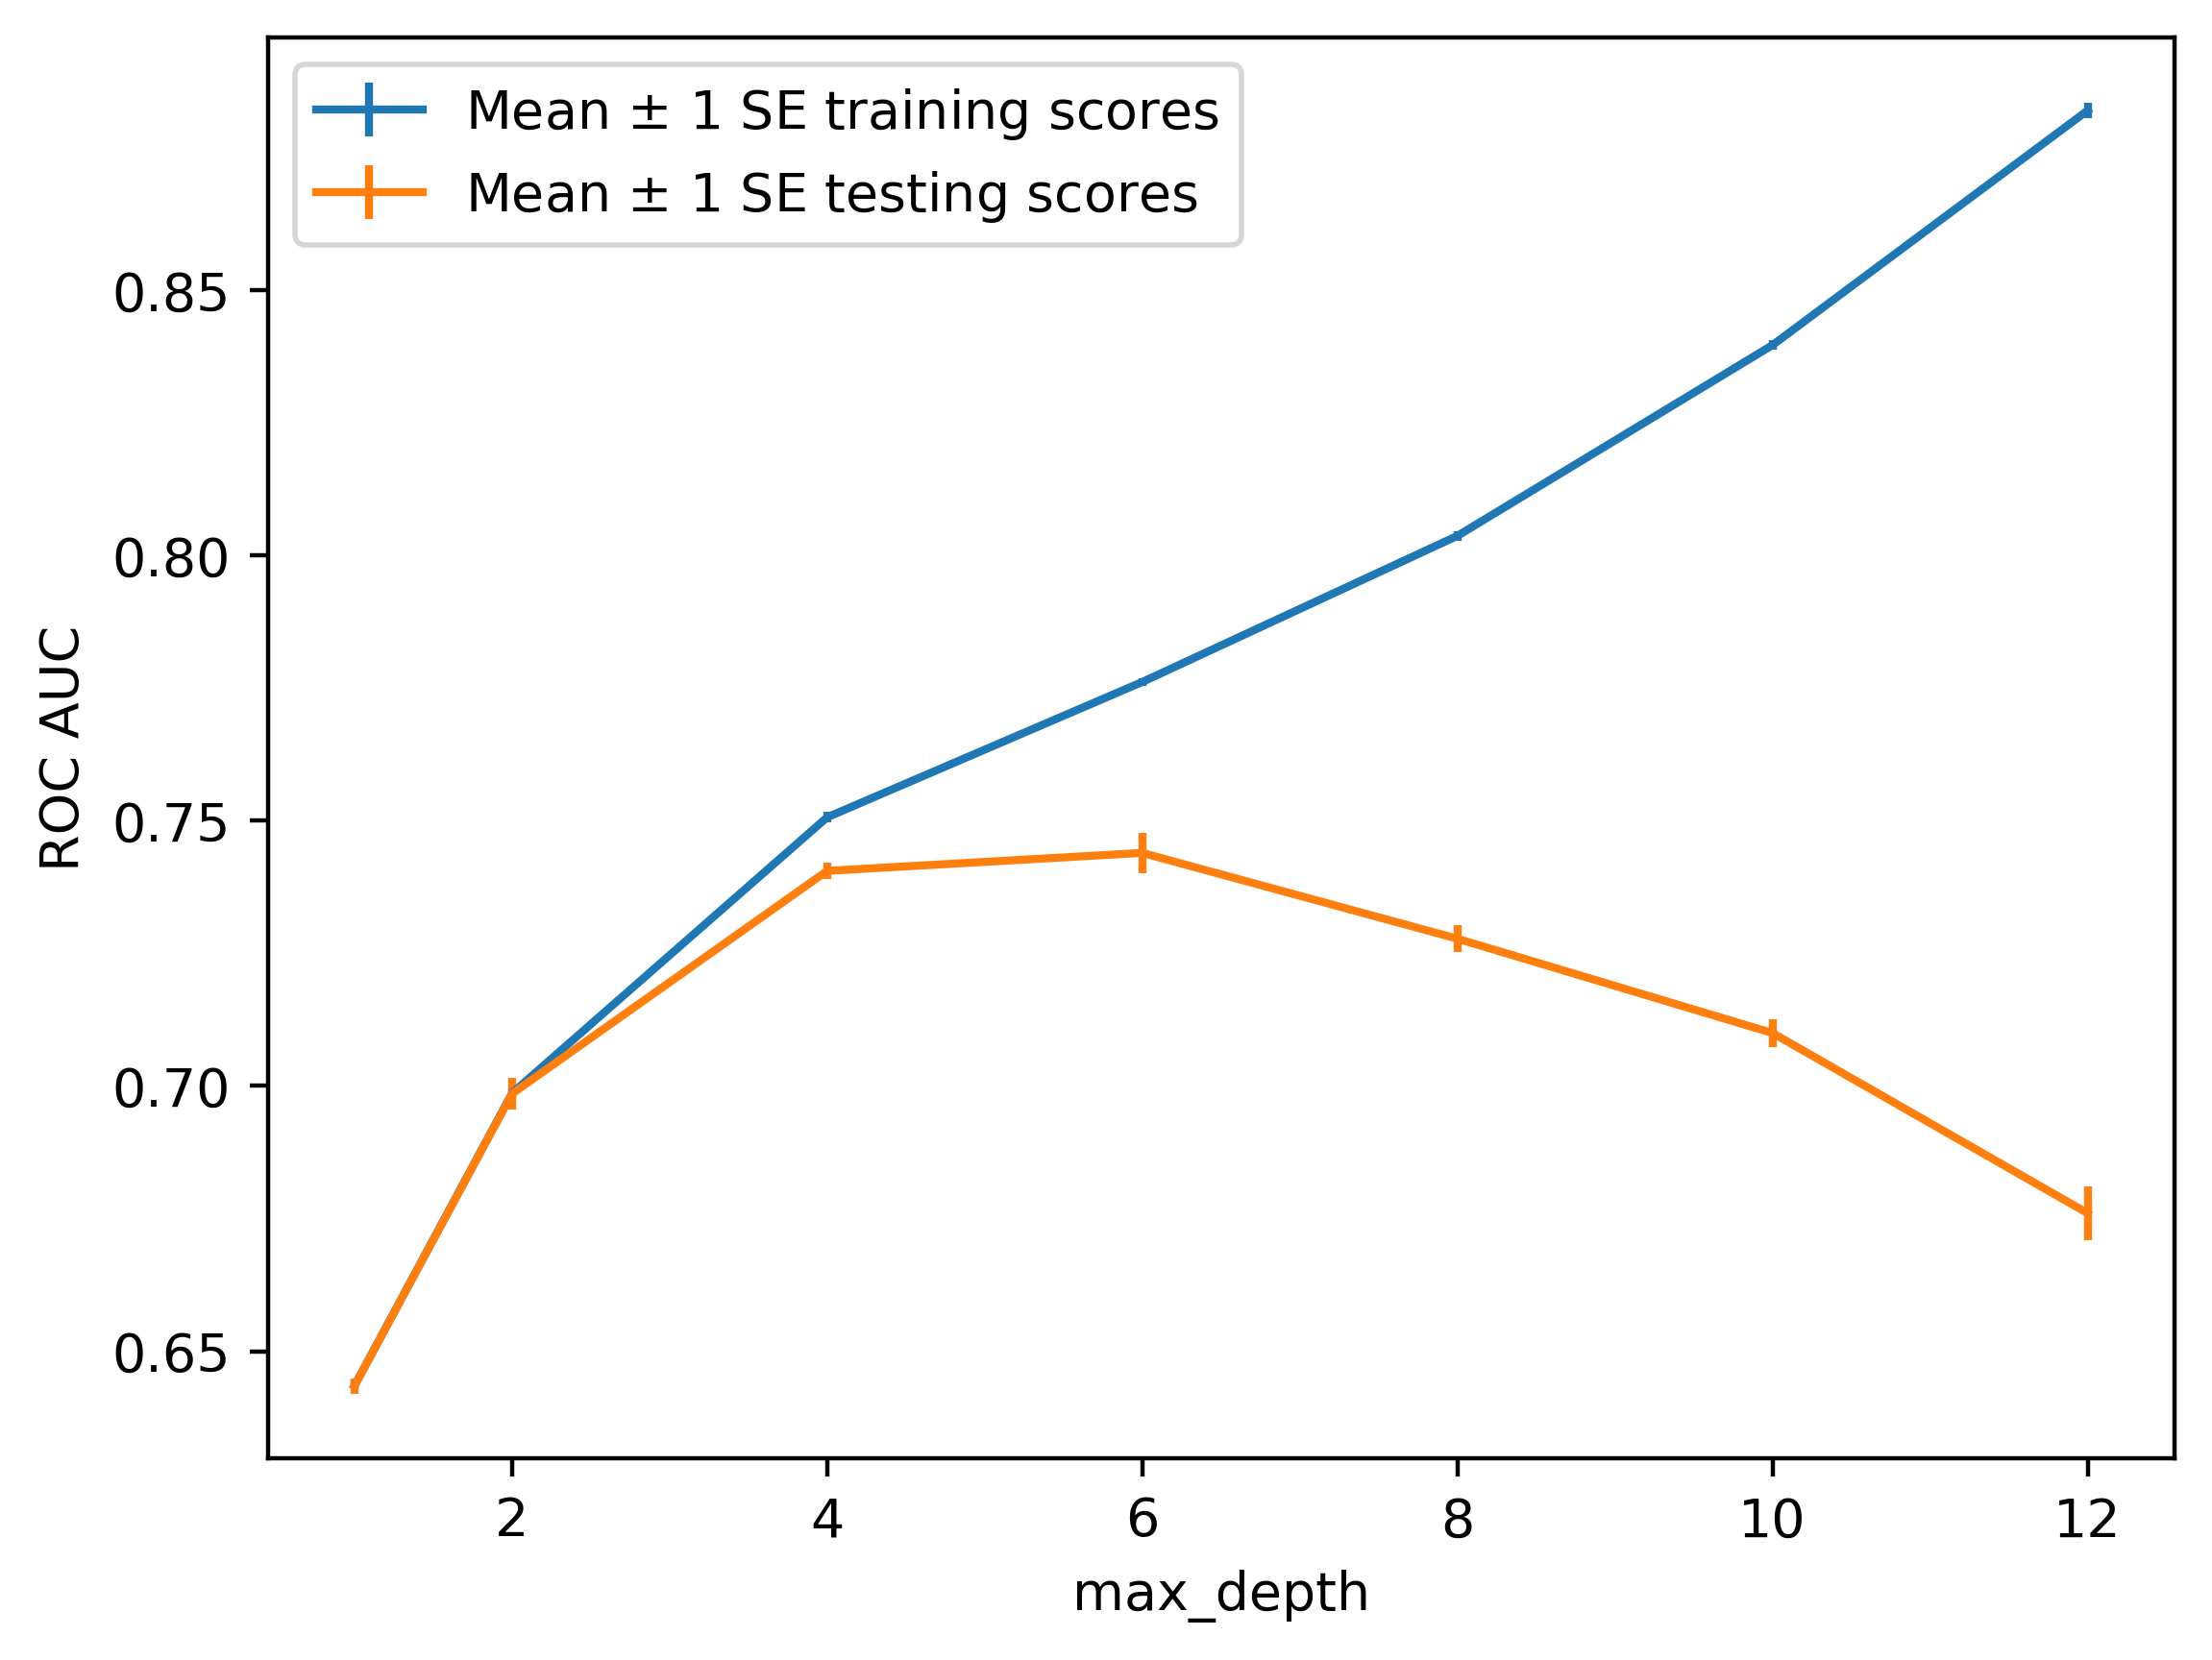

In [44]:
from sklearn.model_selection import GridSearchCV
params = {'max_depth': [1, 2, 4, 6, 8, 10, 12]}  # parameters
dt = tree.DecisionTreeClassifier()  # tree modal
cv = GridSearchCV(dt, param_grid=params, scoring='roc_auc',
                 n_jobs=None, refit=True, cv=4, verbose=1,
                 error_score=np.nan,
                 return_train_score=True)  # cv is the best model.
cv.fit(X_train, y_train)

# Plot the results
cv_results_df = pd.DataFrame(cv.cv_results_)
ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
           cv_results_df['mean_train_score'],
           yerr=cv_results_df['std_train_score']/np.sqrt(4),
           label='Mean $\pm$ 1 SE training scores')
ax.errorbar(cv_results_df['param_max_depth'],
           cv_results_df['mean_test_score'],
           yerr=cv_results_df['std_test_score']/np.sqrt(4),
           label='Mean $\pm$ 1 SE testing scores')
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.show()

## 2.1.3. Bài tập thực hành 1: Dữ liệu Titanic

### Mục tiêu
- Xây dựng mô hình dự đoán khả năng sống sót của hành khách trên tàu Titanic
- So sánh hiệu suất của Decision Tree và Random Forest
- Phân tích các yếu tố ảnh hưởng đến khả năng sống sót

### Import thư viện và nạp dữ liệu

In [45]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Hiển thị thông tin cơ bản về dữ liệu
print("Kích thước tập train:", train_data.shape)
print("\nCác cột trong dữ liệu:")
print(train_data.columns.tolist())
print("\nThống kê cơ bản:")
print(train_data.describe())

Kích thước tập train: (891, 12)

Các cột trong dữ liệu:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Thống kê cơ bản:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000 

### Tiền xử lý dữ liệu
1. Xử lý dữ liệu thiếu
2. Mã hóa biến phân loại
3. Chuẩn bị features

In [46]:
# Xử lý dữ liệu thiếu
def preprocess_data(df):
    # Điền giá trị thiếu cho Age bằng trung bình
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    
    # Điền giá trị thiếu cho Embarked bằng giá trị phổ biến nhất
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    # Điền giá trị thiếu cho Fare bằng trung vị
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    # Mã hóa biến phân loại
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked')
    df = pd.concat([df, embarked_dummies], axis=1)
    
    # Chọn features
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 
               'Embarked_C', 'Embarked_Q', 'Embarked_S']
    
    return df[features]

# Xử lý dữ liệu train và test
X_train = preprocess_data(train_data)
y_train = train_data['Survived']
X_test = preprocess_data(test_data)

print("Features được sử dụng:", X_train.columns.tolist())

Features được sử dụng: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


### Xây dựng và đánh giá mô hình Decision Tree

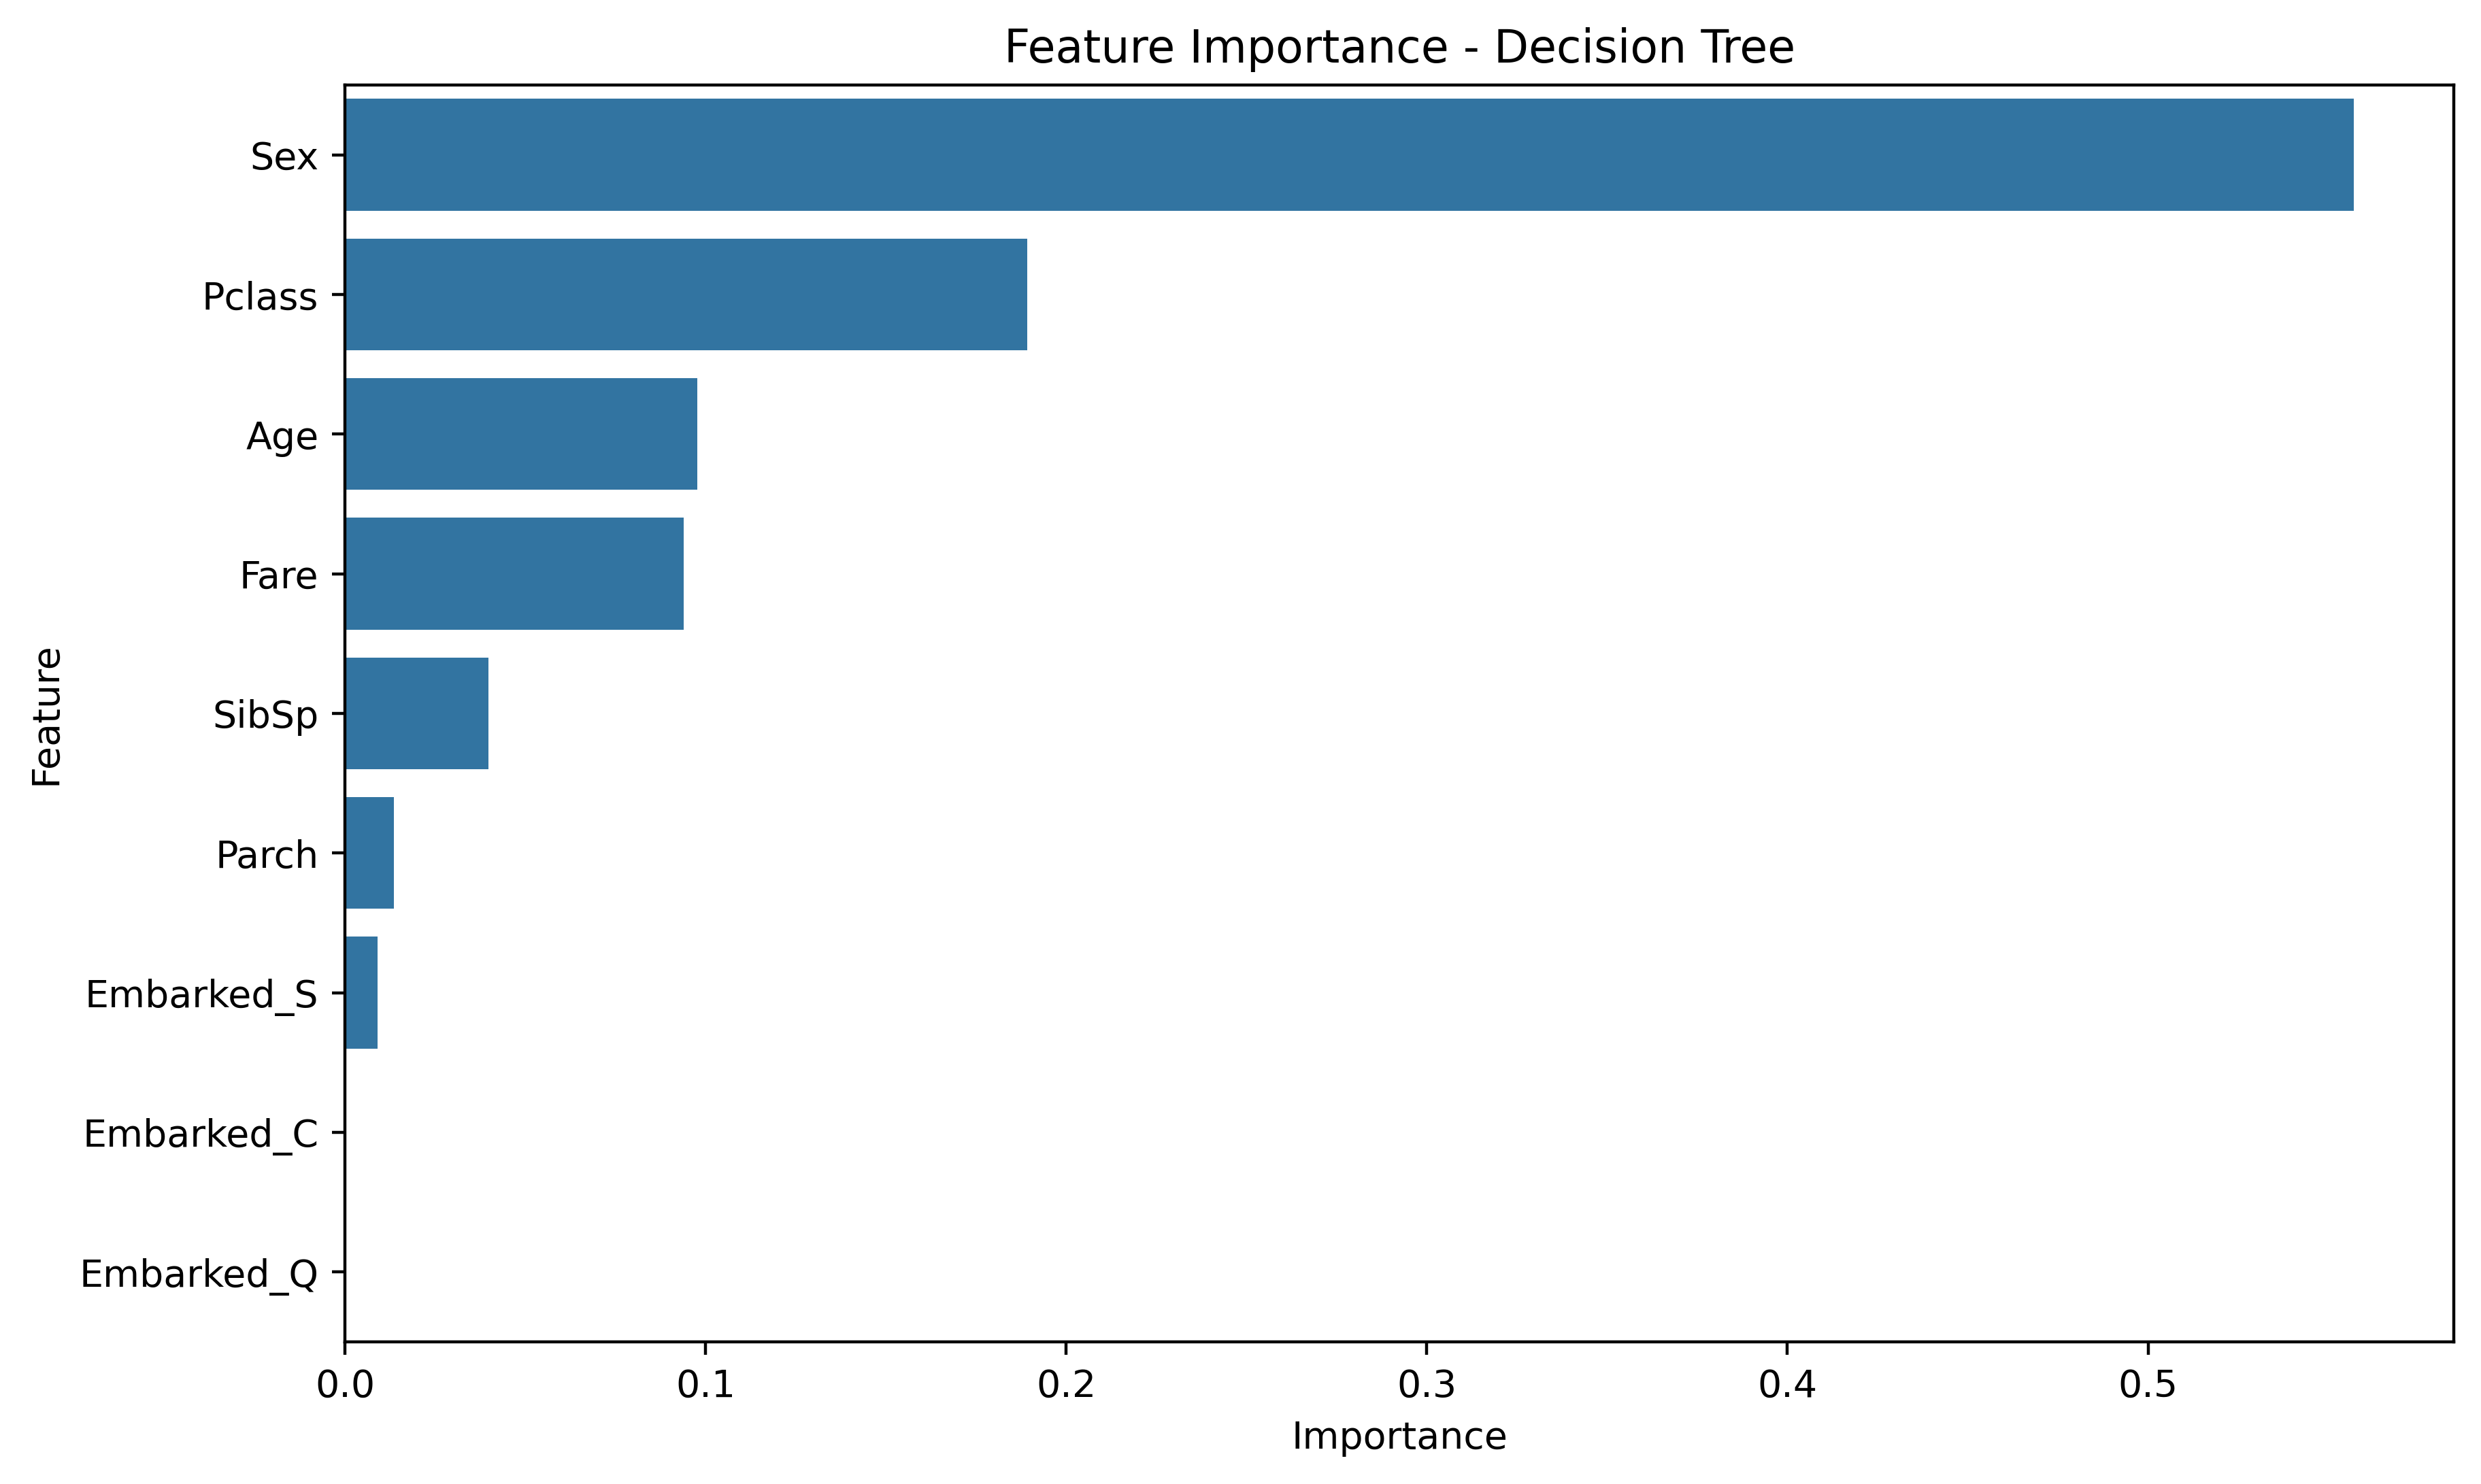

In [47]:
# Khởi tạo và huấn luyện Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_clf.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred_dt = dt_clf.predict(X_test)

# Hiển thị feature importance
feat_importance_dt = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_clf.feature_importances_
})
feat_importance_dt = feat_importance_dt.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_dt)
plt.title('Feature Importance - Decision Tree')
plt.show()

### Xây dựng và đánh giá mô hình Random Forest

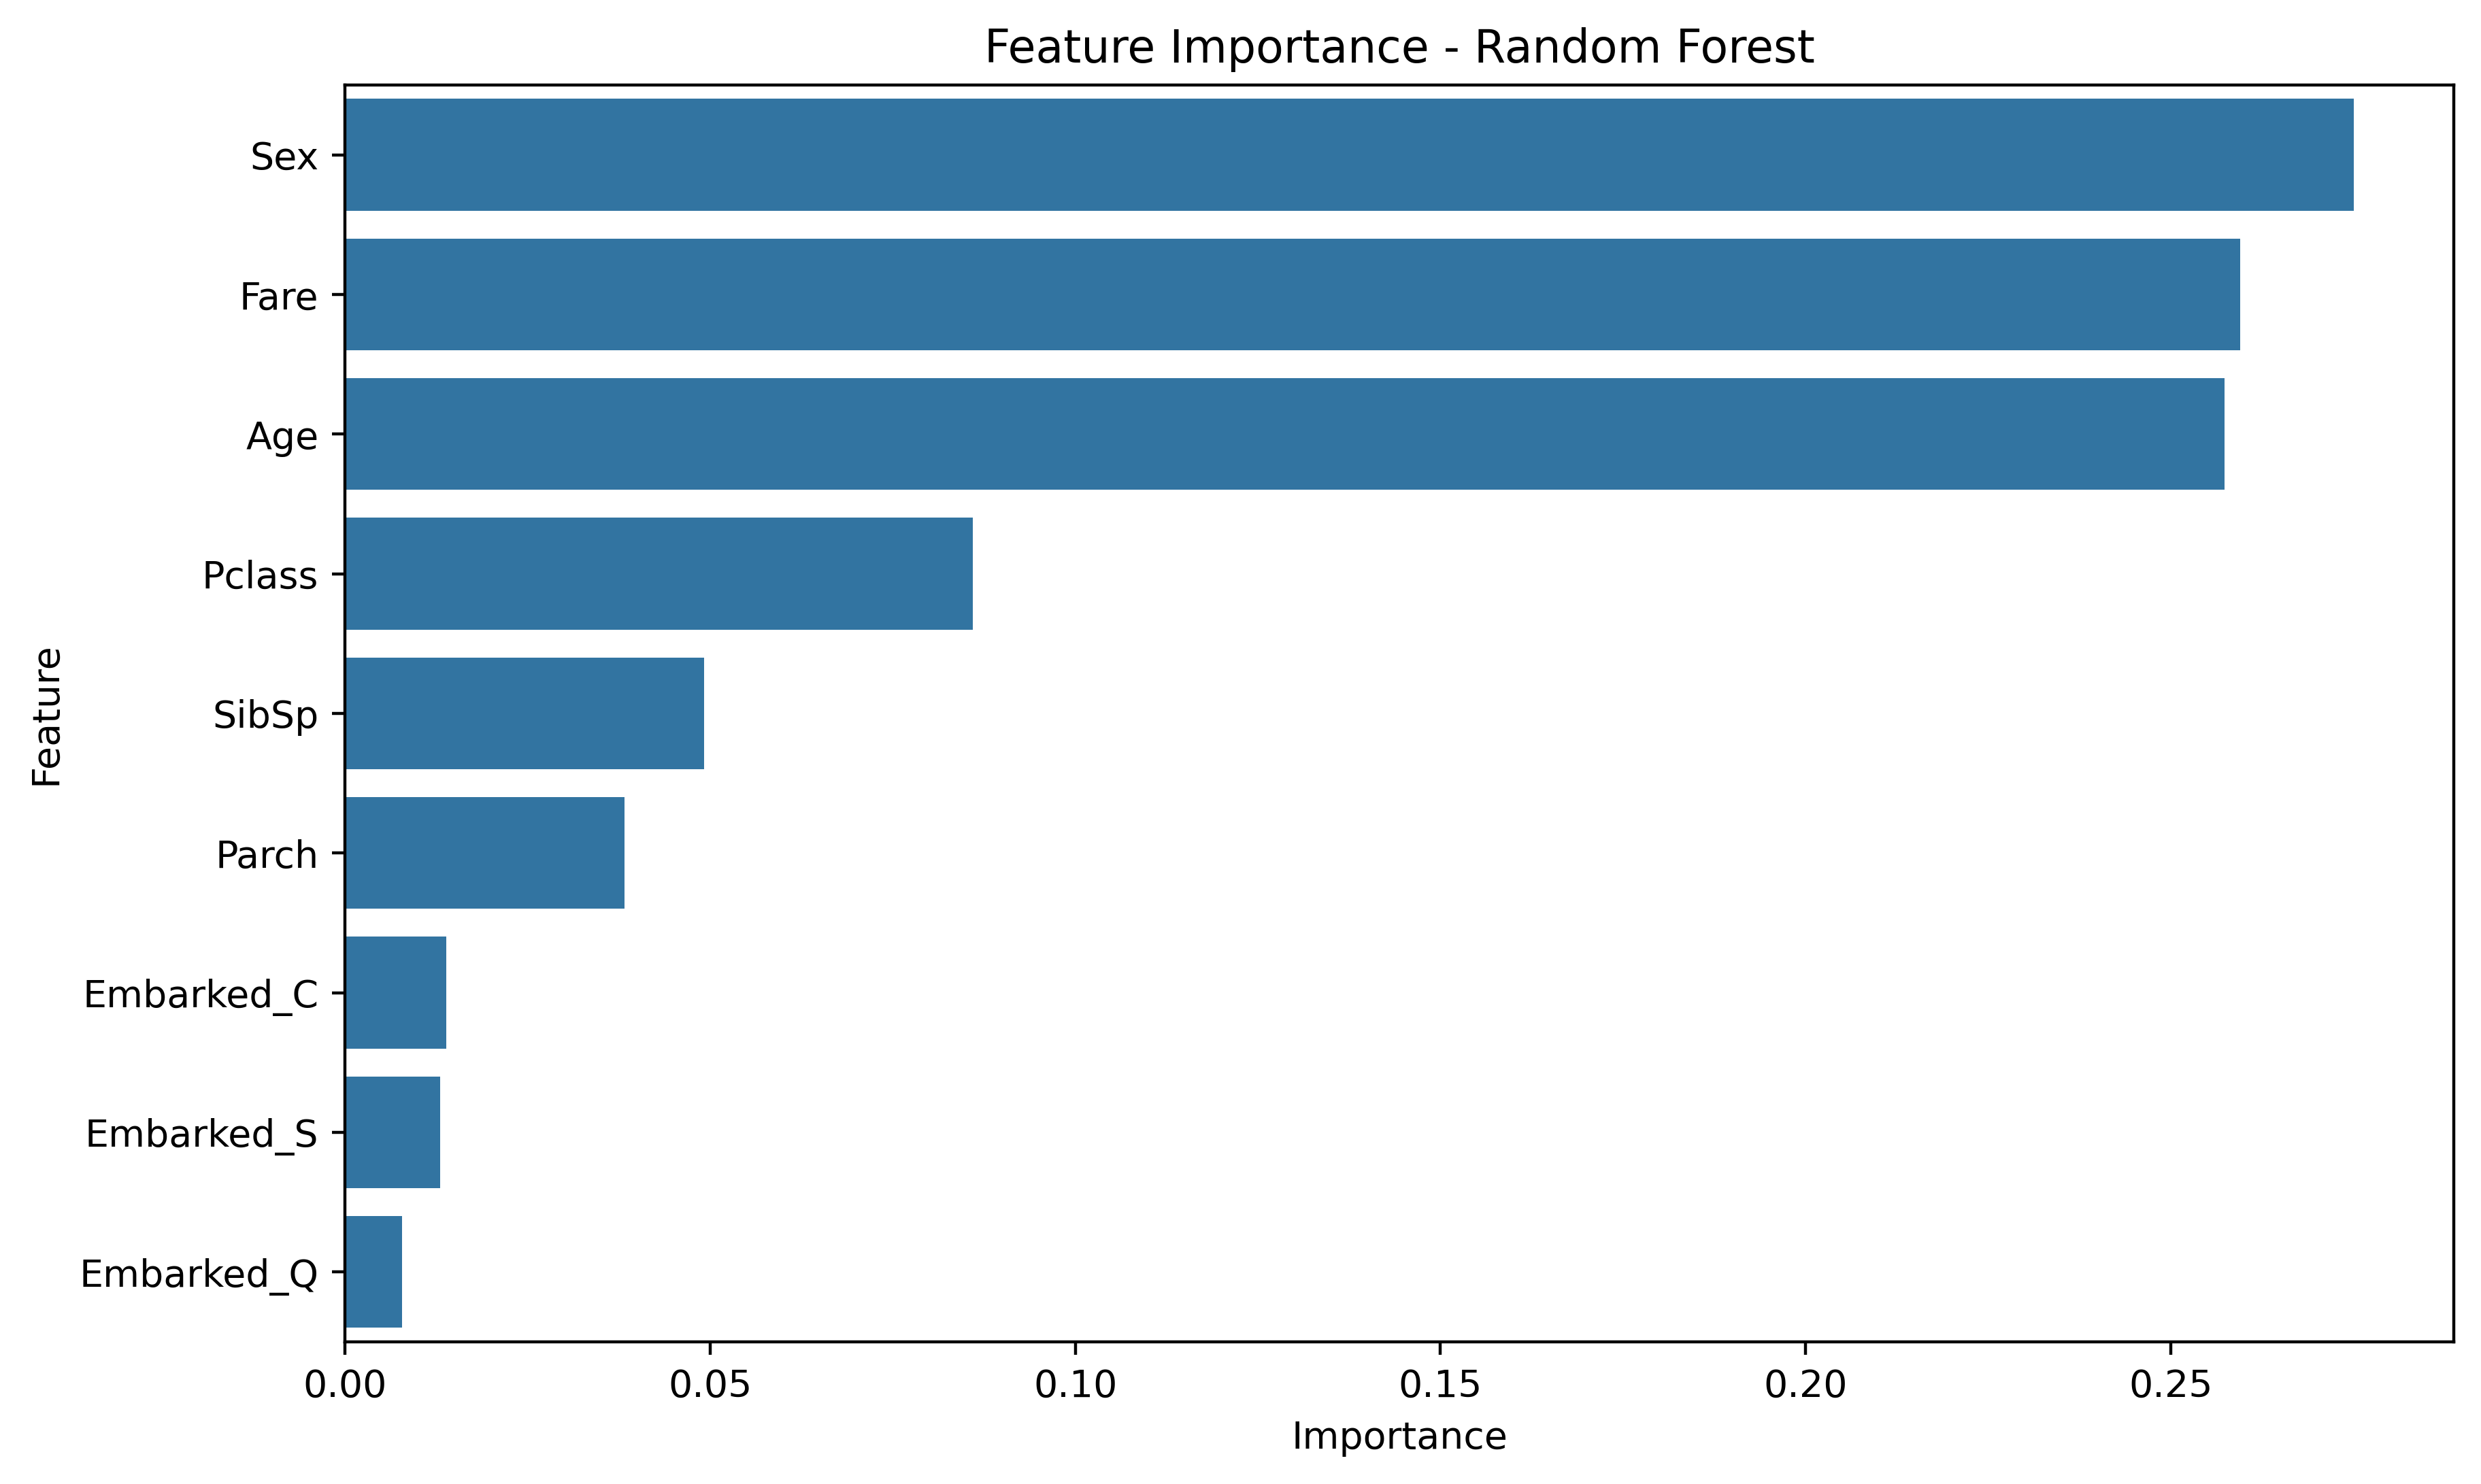

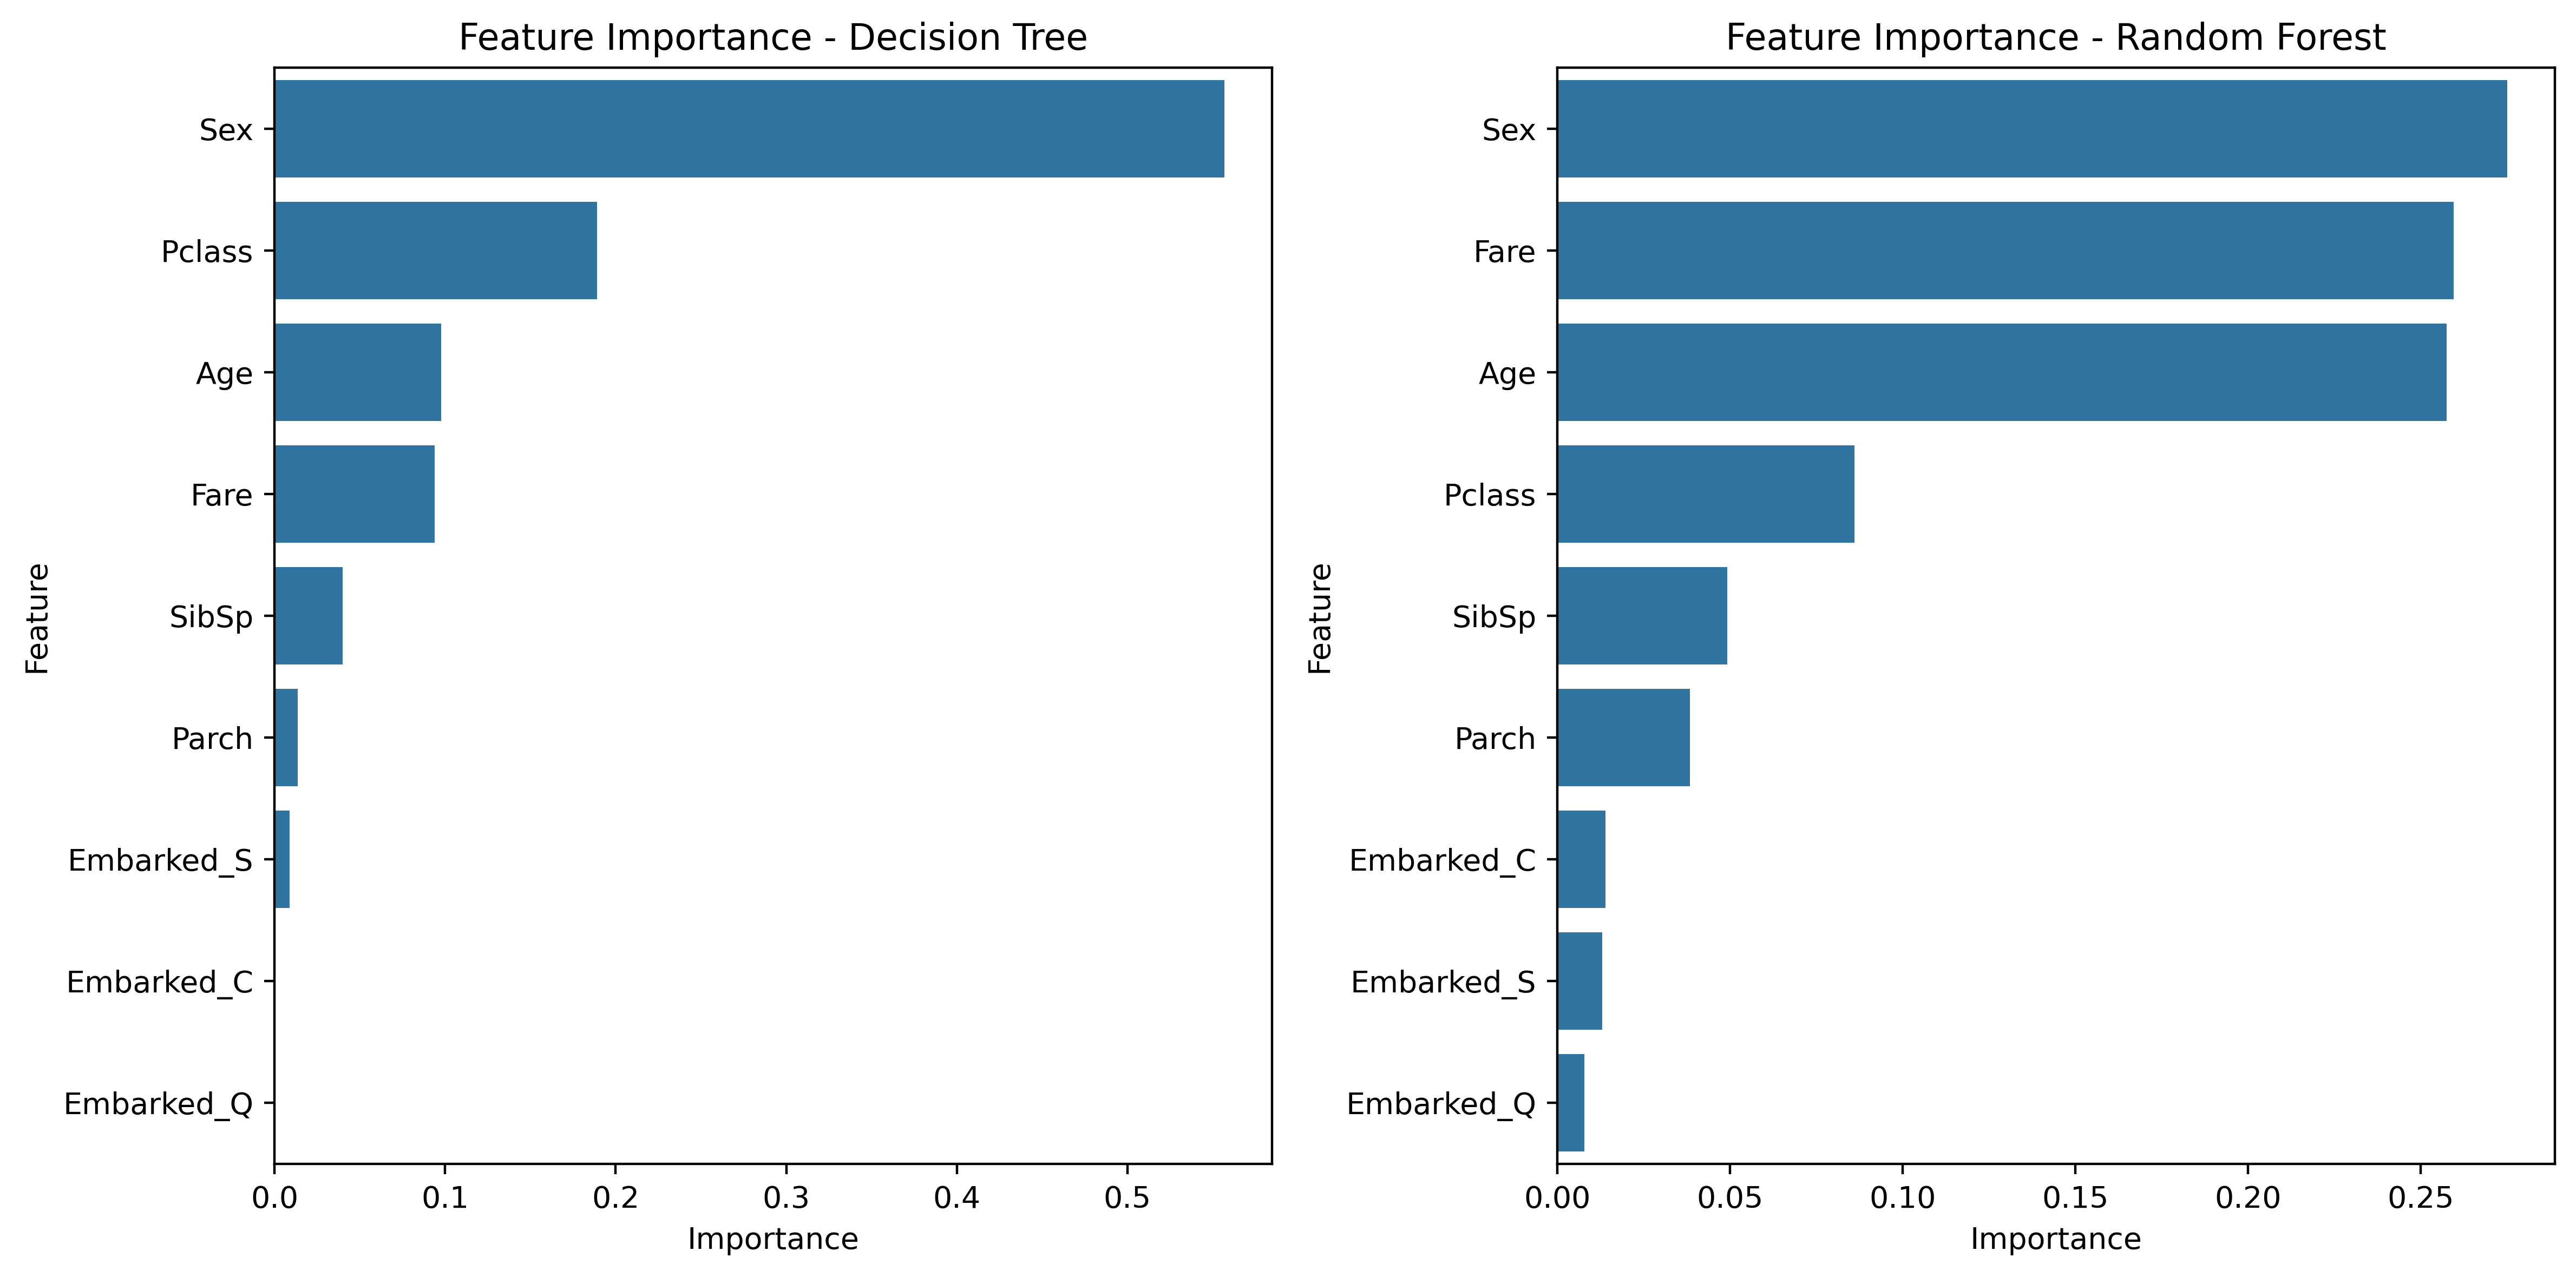

In [48]:
# Khởi tạo và huấn luyện Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred_rf = rf_clf.predict(X_test)

# Hiển thị feature importance
feat_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_clf.feature_importances_
})
feat_importance_rf = feat_importance_rf.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_rf)
plt.title('Feature Importance - Random Forest')
plt.show()

# So sánh feature importance giữa Decision Tree và Random Forest
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Importance', y='Feature', data=feat_importance_dt)
plt.title('Feature Importance - Decision Tree')

plt.subplot(1, 2, 2)
sns.barplot(x='Importance', y='Feature', data=feat_importance_rf)
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

## 2.1.4. Bài tập thực hành 2: Dự đoán bệnh tiểu đường

### Mục tiêu
- Phân tích dữ liệu bệnh tiểu đường
- Xây dựng mô hình dự đoán nguy cơ mắc bệnh tiểu đường
- So sánh hiệu suất của Decision Tree và Random Forest

### Import thư viện và nạp dữ liệu

In [49]:
# Import thư viện
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv('diabetes_prediction_dataset.csv')

# Hiển thị thông tin cơ bản về dữ liệu
print("Kích thước dữ liệu:", df.shape)
print("\nThông tin các cột:")
print(df.info())
print("\nThống kê mô tả:")
print(df.describe())

Kích thước dữ liệu: (100000, 9)

Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

Thống kê mô tả:
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.

### Tiền xử lý dữ liệu
1. Kiểm tra và xử lý dữ liệu thiếu
2. Mã hóa biến phân loại
3. Chuẩn hóa dữ liệu số

In [50]:
# Kiểm tra dữ liệu thiếu
print("Số lượng giá trị thiếu trong mỗi cột:")
print(df.isnull().sum())

# Mã hóa biến phân loại
categorical_cols = ['gender', 'smoking_history']
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Tách features và target
X = df_encoded.drop('diabetes', axis=1)
y = df_encoded['diabetes']

# Chia dữ liệu thành tập train và test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nKích thước dữ liệu sau khi xử lý:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Số lượng giá trị thiếu trong mỗi cột:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Kích thước dữ liệu sau khi xử lý:
X_train: (80000, 15)
X_test: (20000, 15)
y_train: (80000,)
y_test: (20000,)


### Xây dựng và đánh giá mô hình Decision Tree

Decision Tree Results:
Accuracy: 0.97215

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18292
           1       1.00      0.67      0.81      1708

    accuracy                           0.97     20000
   macro avg       0.99      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000


Accuracy: 0.97215

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18292
           1       1.00      0.67      0.81      1708

    accuracy                           0.97     20000
   macro avg       0.99      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



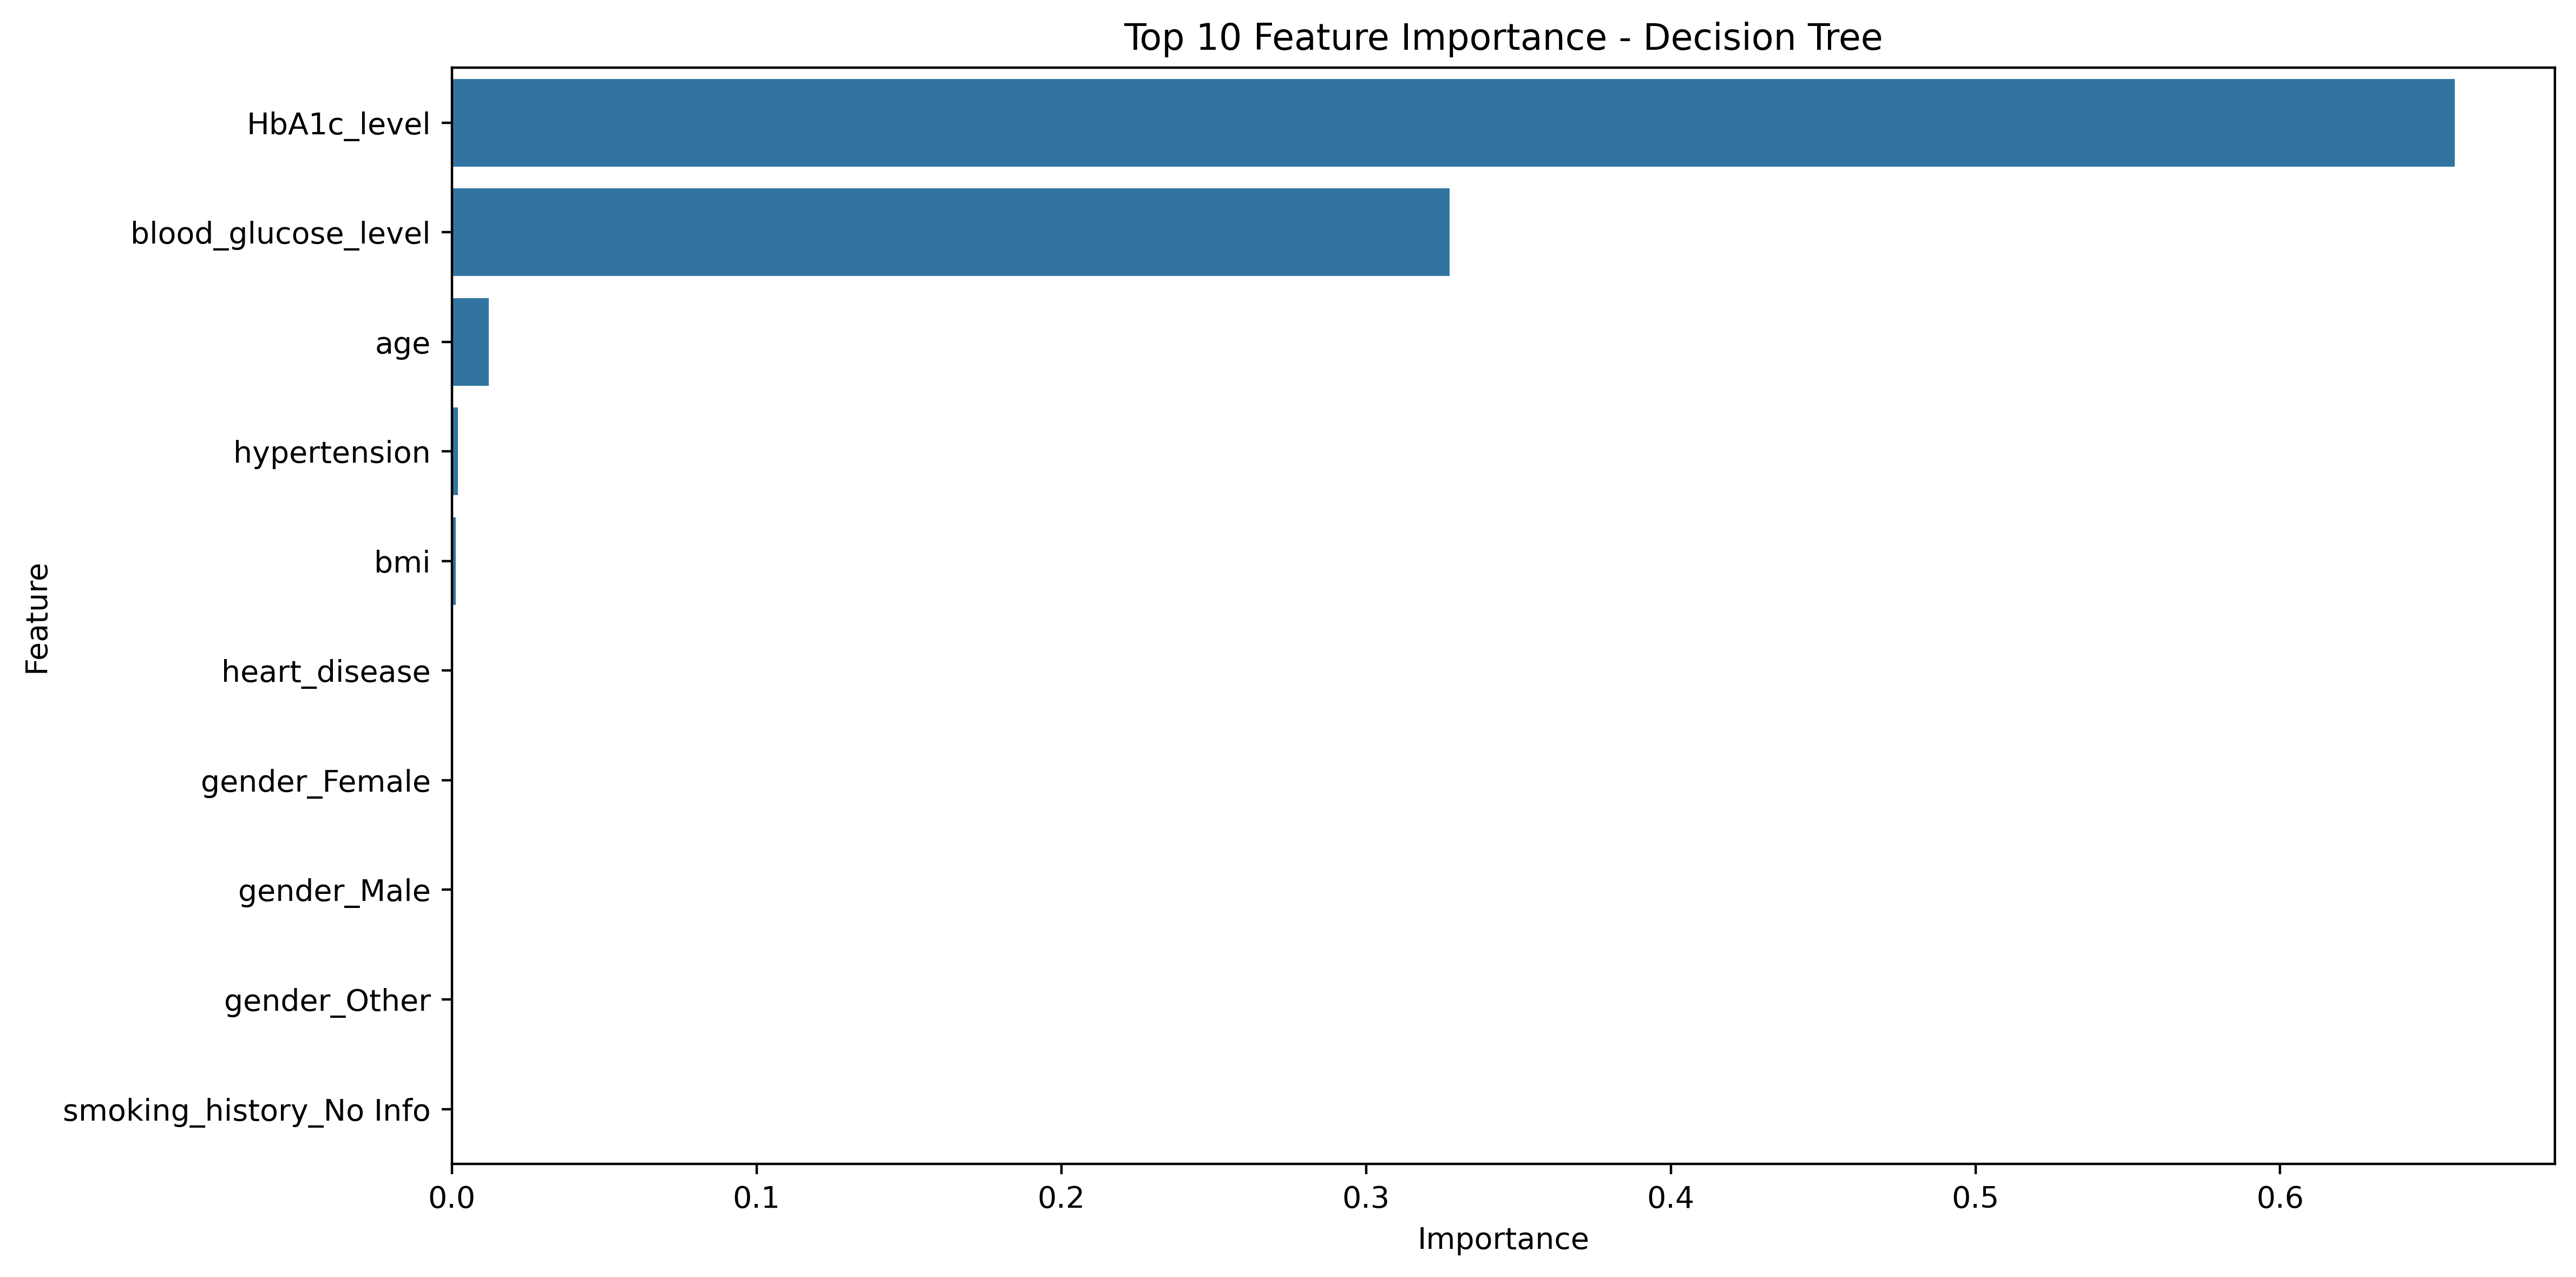

In [51]:
# Xây dựng và huấn luyện Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Vẽ feature importance
feat_importance_dt = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt.feature_importances_
})
feat_importance_dt = feat_importance_dt.sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_dt.head(10))
plt.title('Top 10 Feature Importance - Decision Tree')
plt.tight_layout()
plt.show()

### Xây dựng và đánh giá mô hình Random Forest

Random Forest Results:
Accuracy: 0.97005

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



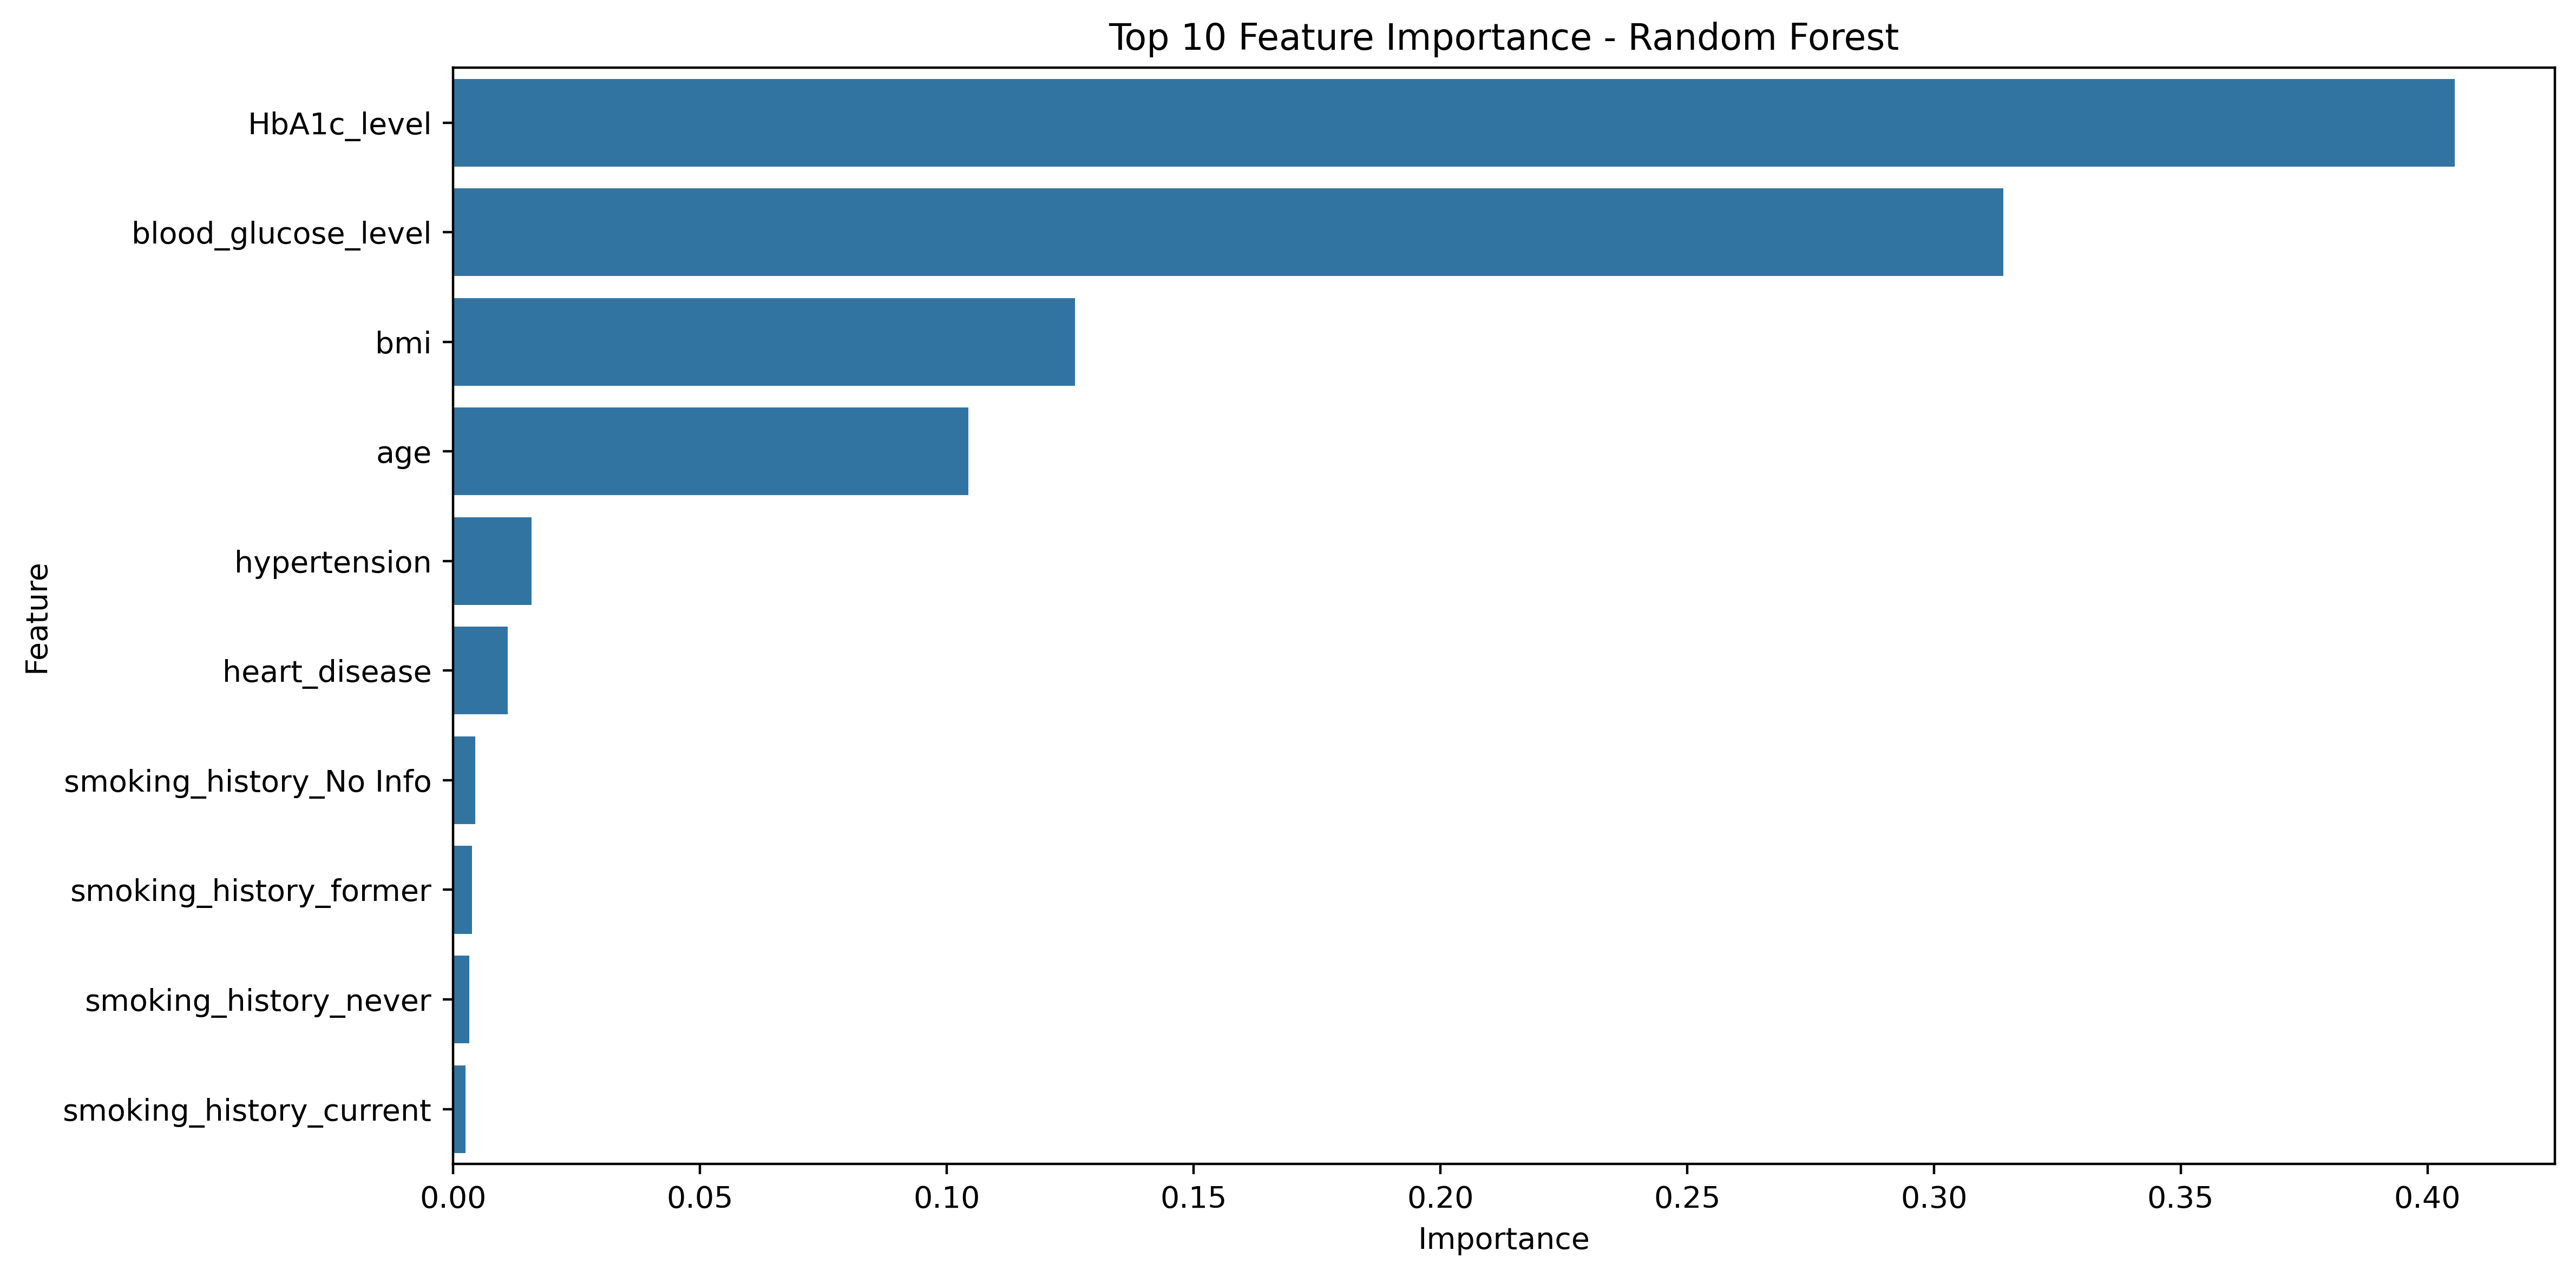

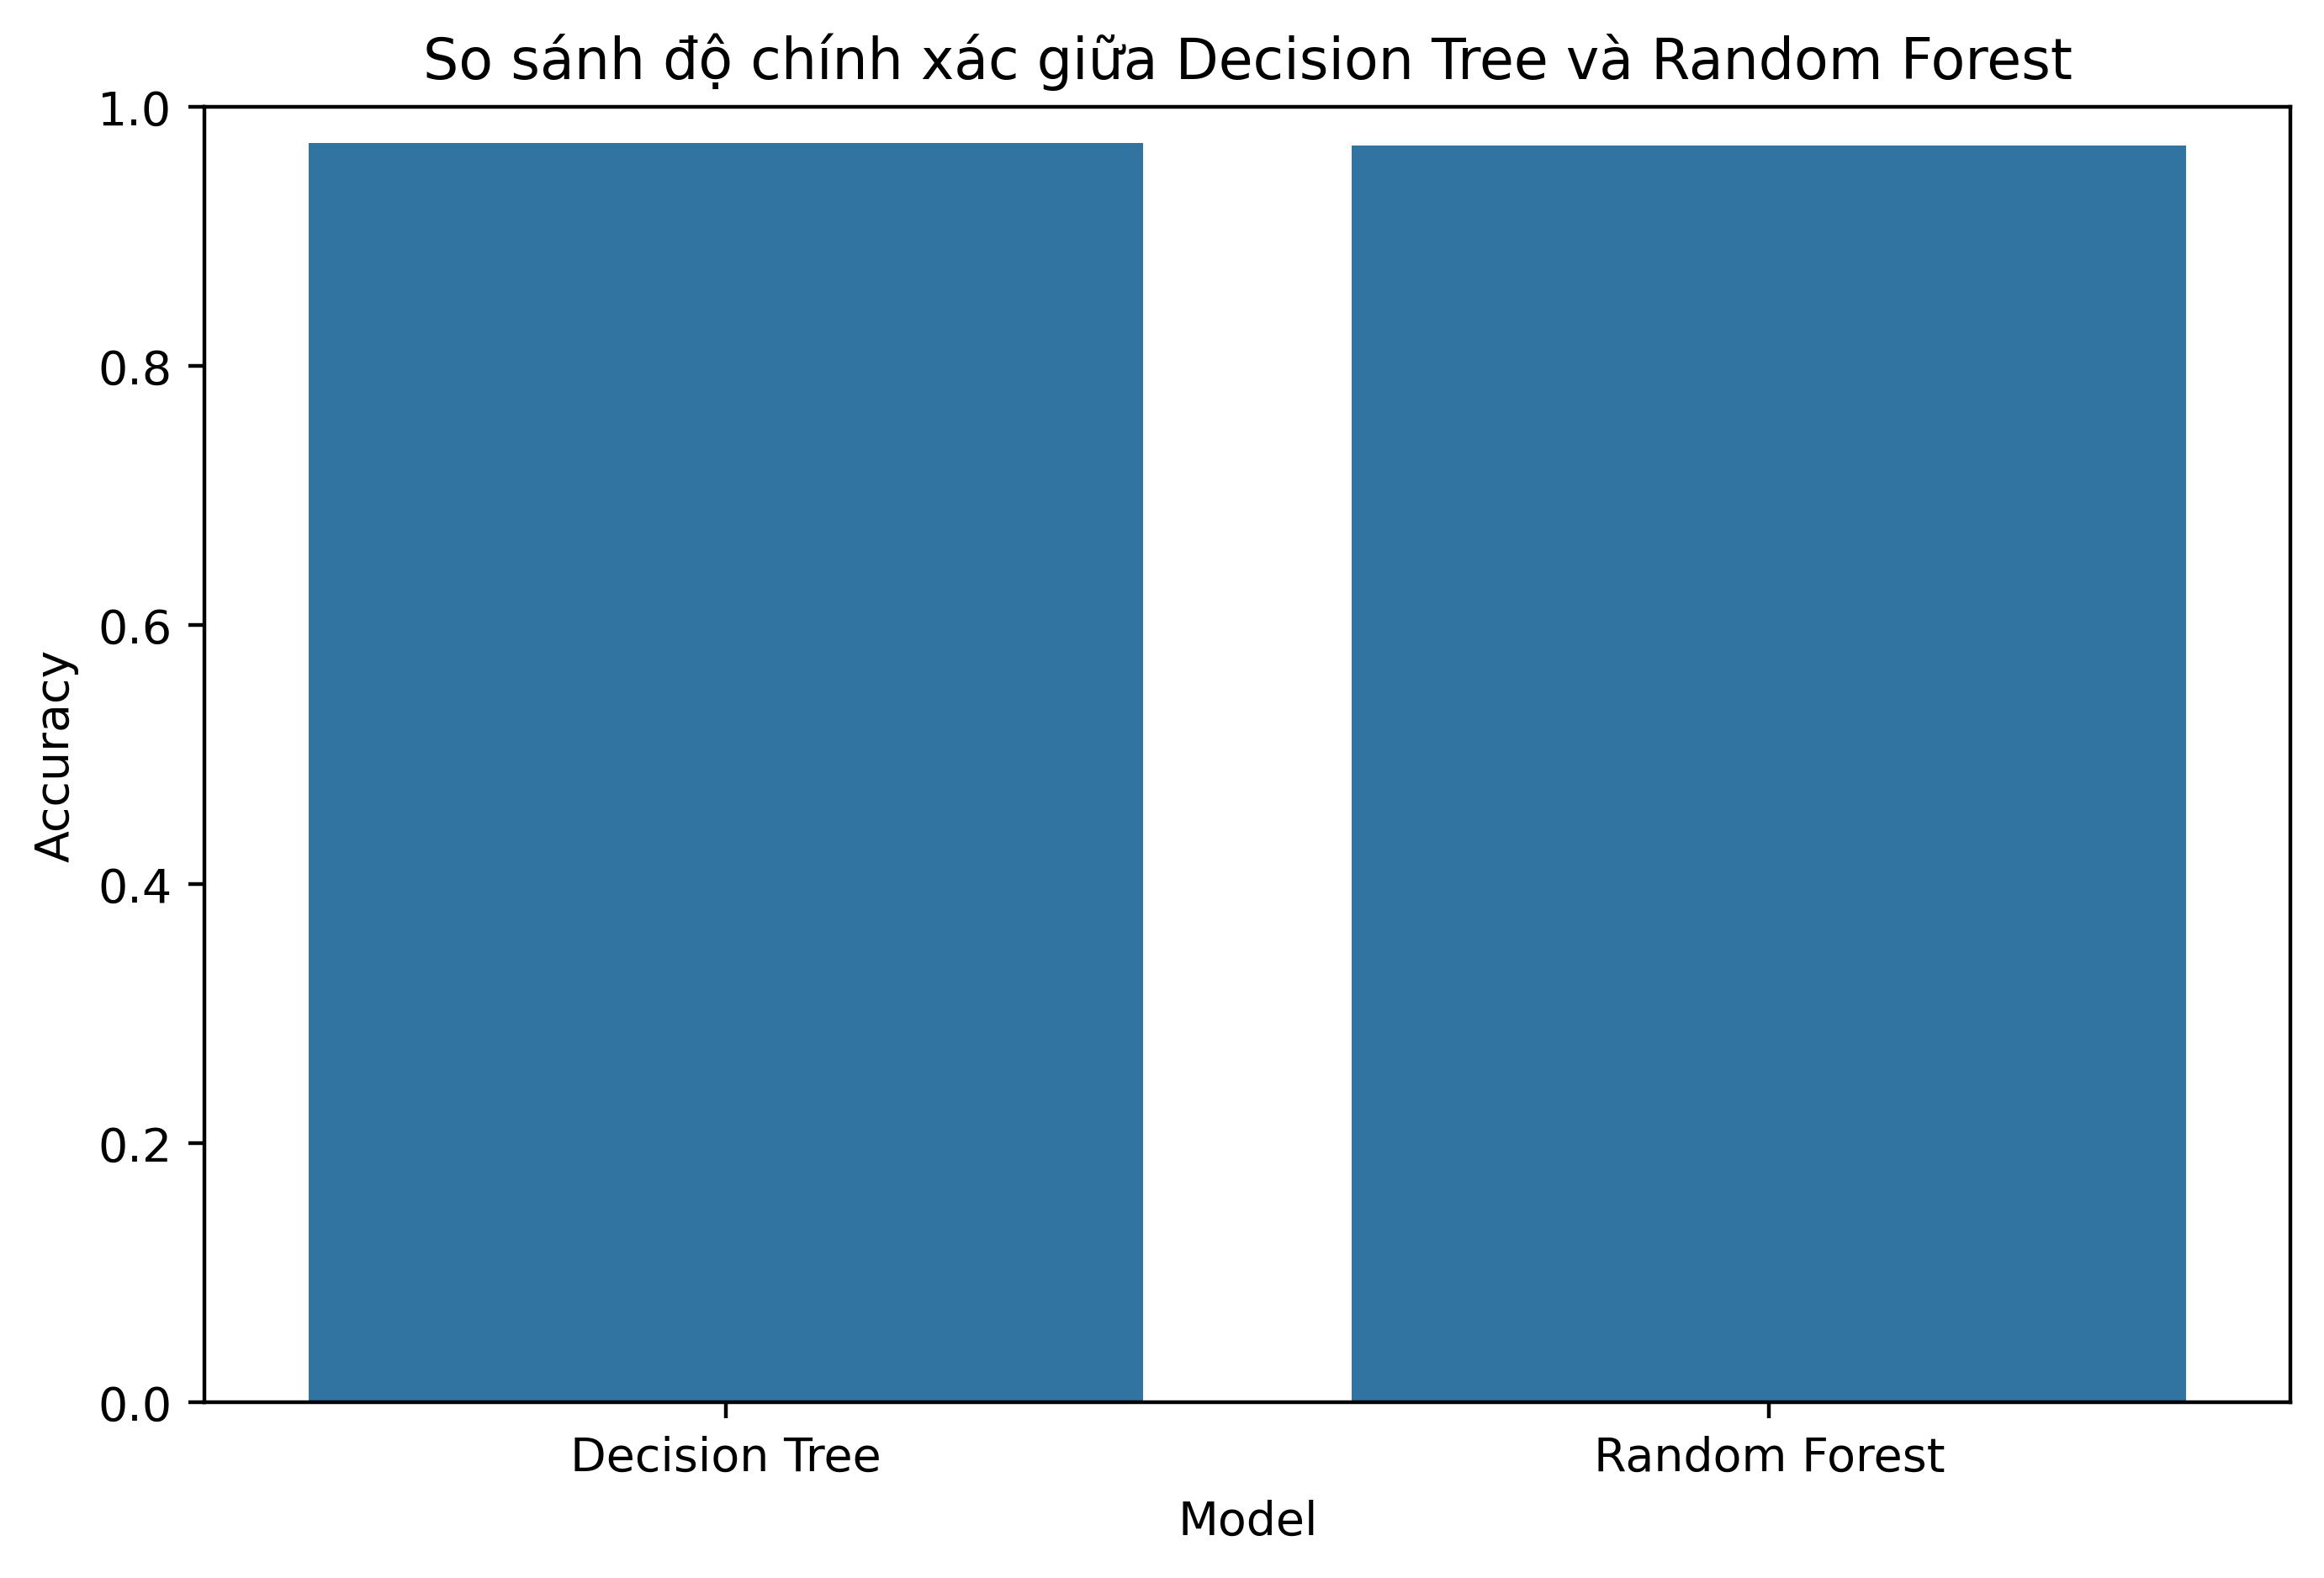

In [52]:
# Xây dựng và huấn luyện Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Vẽ feature importance
feat_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})
feat_importance_rf = feat_importance_rf.sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_rf.head(10))
plt.title('Top 10 Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

# So sánh hiệu suất giữa Decision Tree và Random Forest
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt),
                accuracy_score(y_test, y_pred_rf)]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('So sánh độ chính xác giữa Decision Tree và Random Forest')
plt.ylim(0, 1)
plt.show()

### Kết luận

1. **Hiệu suất mô hình**:
   - So sánh độ chính xác giữa Decision Tree và Random Forest
   - Phân tích ưu và nhược điểm của từng mô hình

2. **Feature Importance**:
   - Các yếu tố quan trọng nhất ảnh hưởng đến nguy cơ mắc bệnh tiểu đường
   - So sánh sự khác biệt trong đánh giá tầm quan trọng của features giữa hai mô hình

3. **Đề xuất**:
   - Cải thiện mô hình bằng cách điều chỉnh hyperparameters
   - Thu thập thêm dữ liệu hoặc features có liên quan
   - Kết hợp với các phương pháp khác để nâng cao hiệu suất